# Notebook to process lysosomalmorphology from cellprofiler features - this time from a merged cell CSV aready created
Inputs Required
 - Database with cellprofiler outputs
   - Mainly use the Per_Cell table for per-cell features
     - Intensity
     - AreaShape features
     - Ratio of organelle area to total cell area
     - Texture features
     - Granularity features
     - Radial intensity distribution about nucleus
   - May additionally want to use mitochdondria or lysosomes.csv if analyzing these specifically 
     - Note that lysosome segmentation is not perfect (but i'm proud of it)
 - Metadata CSV representing 96-well platemap
   - Long-form table containing passage number, staining conditons, treatments, etc
   - Produced automatically from an 8x12 table with the 96Well_PlateMap code
Outputs
- graphs for individual features
- clustering
## Set your paths here

In [24]:
# Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import sqlite3

# plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns
import pingouin as pg
import re

from scipy import stats

from plate_information import *
from plate_preprocessing import *
from mitolyso_plot_functions import *

## Import the big csv

In [25]:
# import from a giant csv
# csvpath = "/Volumes/AllieS/Morphology_data/"

# csvpath = "/Volumes/AllieS/2025_OrganelleMorphology_MitoLyso/test_mitoimprov_v5"
csvpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/lyso_seg_testing/v2"
filename = "Cell.csv"
metadata_path = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_Organelle_Segmentation/MitoSegmentation"
metadata_filename = "MitochondriaSegmentationSubsetImages_metaonly_new.csv"
# filename = "total_combined_cell_borders_excluded.csv"

cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))
nuc_df_mitolyso = pd.read_csv(os.path.join(csvpath, "Nuclei.csv"))
nuc_df_mitolyso = nuc_df_mitolyso.add_prefix("Nuclei_")

relabeled_mito_df_mitolyso = pd.read_csv(os.path.join(csvpath, "RelabeledLyso1.csv"))
relabeled_mito_df_mitolyso = relabeled_mito_df_mitolyso.add_prefix("RelabeledLyso_")
# image_df = pd.read_csv(os.path.join(csvpath, "Image.csv"))
combined_cell_df_mitolyso = pd.merge(
    cell_df_mitolyso,
    nuc_df_mitolyso,
    left_on=["ImageNumber", "Parent_Nuclei"],
    right_on=["Nuclei_ImageNumber", "Nuclei_ObjectNumber"],
    #suffixes=("", ""),
    how="left",
)
combined_cell_df_mitolyso = pd.merge(
    combined_cell_df_mitolyso,
    relabeled_mito_df_mitolyso,
    left_on=["ImageNumber", "ObjectNumber"],
    right_on=["RelabeledLyso_ImageNumber", "RelabeledLyso_ObjectNumber"],
    #suffixes=("", ""),
    how="left",
)
    
# combined_cell_df_mitolyso = pd.merge(combined_cell_df_mitolyso, image_df, left_on=["ImageNumber"], right_on=["ImageNumber"], suffixes=("", "_Image"))
# filter_df = enforce_objects_one_to_one(combined_cell_df_mitolyso)
display(f"cell_df_mitolyso.shape: {cell_df_mitolyso.shape}")
display(f"combined_cell_df_mitolyso.shape: {combined_cell_df_mitolyso.shape}")
# print(cell_df.shape, " ", filter_df.shape)
display(combined_cell_df_mitolyso.head())

'cell_df_mitolyso.shape: (875, 242)'

'combined_cell_df_mitolyso.shape: (875, 461)'

,ImageNumber,ObjectNumber,Metadata_AllGroups,Metadata_C,Metadata_Cell_Unique_ID,Metadata_Channel,Metadata_ChannelName,Metadata_ColorFormat,Metadata_EmptyImage_Cells,Metadata_EmptyImage_Nuclei,...,RelabeledLyso_AreaShape_Zernike_8_8,RelabeledLyso_AreaShape_Zernike_9_1,RelabeledLyso_AreaShape_Zernike_9_3,RelabeledLyso_AreaShape_Zernike_9_5,RelabeledLyso_AreaShape_Zernike_9_7,RelabeledLyso_AreaShape_Zernike_9_9,RelabeledLyso_Location_Center_X,RelabeledLyso_Location_Center_Y,RelabeledLyso_Number_Object_Number,RelabeledLyso_Parent_Lysosomes
0,1,1,NaN,0,NaN,NaN,NaN,monochrome,0,0,...,0.001269,0.001734,0.003427,0.002304,0.001965,0.000605,1296.992926,804.349891,1,378
1,1,2,NaN,0,NaN,NaN,NaN,monochrome,0,0,...,0.000373,0.005321,0.003583,0.002000,0.000738,0.000209,792.713385,1406.575169,2,1458
2,2,1,NaN,0,NaN,NaN,NaN,monochrome,0,0,...,0.001161,0.003550,0.002575,0.002353,0.001023,0.000467,1650.077956,720.328144,1,236
3,2,2,NaN,0,NaN,NaN,NaN,monochrome,0,0,...,0.000218,0.010502,0.001678,0.001769,0.002449,0.000634,199.126726,919.410122,2,801
4,3,1,NaN,0,NaN,NaN,NaN,monochrome,0,0,...,0.004638,0.009420,0.004254,0.002212,0.003935,0.002944,1995.429007,83.493627,1,189


In [26]:
#add metadata columns for merging with metadata csv
combined_cell_df_mitolyso["Metadata_RowColField"] = (
    "r"
    + combined_cell_df_mitolyso["Metadata_WellRow"].astype(str).str.rjust(2, "0")
    + "c"
    + combined_cell_df_mitolyso["Metadata_WellColumn"].astype(str).str.rjust(2, "0")
    + "f"
    + combined_cell_df_mitolyso["Metadata_Field"].astype(str).str.rjust(2, "0")
)

combined_cell_df_mitolyso["Metadata_Rep_RowColField"] = (
    "rep"
    + combined_cell_df_mitolyso["Metadata_PlateNumber"].astype(str).str.rjust(2, "0")
    + "_"
    + combined_cell_df_mitolyso["Metadata_RowColField"]
)

combined_cell_df_mitolyso["Metadata_PlateNumber"] = combined_cell_df_mitolyso[
    "Metadata_PlateNumber"
].astype(str)

display(f"combined_cell_df_mitolyso.shape before metadata merge: {combined_cell_df_mitolyso.shape}")

metadata_df = pd.read_csv(os.path.join(metadata_path, metadata_filename))
metadata_df["Metadata_PlateNumber"] = metadata_df["Metadata_PlateNumber"].astype(str)
metadata_df["Metadata_RowColField"] = metadata_df["Metadata_RowColField"].astype(str)

keys = ["Metadata_PlateNumber", "Metadata_RowColField", "Metadata_WellRow", "Metadata_WellColumn", "Metadata_Field"] #, "ObjectNumber"]
display(metadata_df.tail())
combined_cell_df_mitolyso = pd.merge(
    combined_cell_df_mitolyso,
    metadata_df,
    on=keys,
    how="left",
)
display(
    f"combined_cell_df_mitolyso.shape after metadata merge: {combined_cell_df_mitolyso.shape}"
)
display(combined_cell_df_mitolyso.tail())

'combined_cell_df_mitolyso.shape before metadata merge: (875, 463)'

,AllGroups,Metadata_PlateNumber,Cell_Unique_ID,Number_Object_Number,Image_FileName_MitoTracker_MAX,Value,Segmentation,Metadata_RowColField,Metadata_WellRow,Metadata_WellColumn,Metadata_Field,Parent_Nuclei,PassageNumber,Original_Index
137,P13-15,3,61636,2,MAX_ch2-r04c07f03.tif,median,not bad,r04c07f03,4,7,3,1,13,59572
138,P13-15,3,61786,9,MAX_ch2-r04c07f23.tif,median,mix of good/under,r04c07f23,4,7,23,9,13,59713
139,P13-15,1,72157,1,MAX_ch2-r04c04f15.tif,median,good,r04c04f15,4,4,15,1,14,69823
140,P13-15,1,74254,8,MAX_ch2-r06c04f02.tif,highest,oversegmented,r06c04f02,6,4,2,8,14,71865
141,P13-15,1,75368,12,MAX_ch2-r07c04f15.tif,lowest,"undersegmented, sparse",r07c04f15,7,4,15,11,14,72964


'combined_cell_df_mitolyso.shape after metadata merge: (875, 472)'

,ImageNumber,ObjectNumber,Metadata_AllGroups,Metadata_C,Metadata_Cell_Unique_ID,Metadata_Channel,Metadata_ChannelName,Metadata_ColorFormat,Metadata_EmptyImage_Cells,Metadata_EmptyImage_Nuclei,...,Metadata_Rep_RowColField,AllGroups,Cell_Unique_ID,Number_Object_Number_y,Image_FileName_MitoTracker_MAX,Value,Segmentation,Parent_Nuclei_y,PassageNumber,Original_Index
870,137,7,NaN,0,NaN,NaN,NaN,monochrome,0,0,...,rep07_r06c11f29,P13-15,27258,5,MAX_ch2-r06c11f29.tif,median,not bad,4,13,26626
871,137,8,NaN,0,NaN,NaN,NaN,monochrome,0,0,...,rep07_r06c11f29,P13-15,27258,5,MAX_ch2-r06c11f29.tif,median,not bad,4,13,26626
872,137,9,NaN,0,NaN,NaN,NaN,monochrome,0,0,...,rep07_r06c11f29,P13-15,27258,5,MAX_ch2-r06c11f29.tif,median,not bad,4,13,26626
873,137,10,NaN,0,NaN,NaN,NaN,monochrome,0,0,...,rep07_r06c11f29,P13-15,27258,5,MAX_ch2-r06c11f29.tif,median,not bad,4,13,26626
874,137,11,NaN,0,NaN,NaN,NaN,monochrome,0,0,...,rep07_r06c11f29,P13-15,27258,5,MAX_ch2-r06c11f29.tif,median,not bad,4,13,26626


## Setup functions


### Filter out the poorly segmented cells and rename the columns so I don't have to change the old code

## Search Column Names

In [27]:
# colnames
# sns.barplot(filter_df_2, x="AllGroups",y="AreaShape_Area", hue="Plate_Number", palette=colour_dict)
colnames = search_column_name(combined_cell_df_mitolyso, "Lyso")
display(combined_cell_df_mitolyso[colnames])



Query: Lyso
    Children_Lysosomes_Count
    Children_Lysosomes_IJ_Count
    Mean_Lysosomes_AreaShape_Area
    Mean_Lysosomes_AreaShape_BoundingBoxArea
    Mean_Lysosomes_AreaShape_BoundingBoxMaximum_X
    Mean_Lysosomes_AreaShape_BoundingBoxMaximum_Y
    Mean_Lysosomes_AreaShape_BoundingBoxMinimum_X
    Mean_Lysosomes_AreaShape_BoundingBoxMinimum_Y
    Mean_Lysosomes_AreaShape_Center_X
    Mean_Lysosomes_AreaShape_Center_Y
    Mean_Lysosomes_AreaShape_Compactness
    Mean_Lysosomes_AreaShape_ConvexArea
    Mean_Lysosomes_AreaShape_Eccentricity
    Mean_Lysosomes_AreaShape_EquivalentDiameter
    Mean_Lysosomes_AreaShape_EulerNumber
    Mean_Lysosomes_AreaShape_Extent
    Mean_Lysosomes_AreaShape_FormFactor
    Mean_Lysosomes_AreaShape_MajorAxisLength
    Mean_Lysosomes_AreaShape_MaxFeretDiameter
    Mean_Lysosomes_AreaShape_MaximumRadius
    Mean_Lysosomes_AreaShape_MeanRadius
    Mean_Lysosomes_AreaShape_MedianRadius
    Mean_Lysosomes_AreaShape_MinFeretDiameter
    Mean_Lysosomes_Are

,Children_Lysosomes_Count,Children_Lysosomes_IJ_Count,Mean_Lysosomes_AreaShape_Area,Mean_Lysosomes_AreaShape_BoundingBoxArea,Mean_Lysosomes_AreaShape_BoundingBoxMaximum_X,Mean_Lysosomes_AreaShape_BoundingBoxMaximum_Y,Mean_Lysosomes_AreaShape_BoundingBoxMinimum_X,Mean_Lysosomes_AreaShape_BoundingBoxMinimum_Y,Mean_Lysosomes_AreaShape_Center_X,Mean_Lysosomes_AreaShape_Center_Y,...,RelabeledLyso_AreaShape_Zernike_8_8,RelabeledLyso_AreaShape_Zernike_9_1,RelabeledLyso_AreaShape_Zernike_9_3,RelabeledLyso_AreaShape_Zernike_9_5,RelabeledLyso_AreaShape_Zernike_9_7,RelabeledLyso_AreaShape_Zernike_9_9,RelabeledLyso_Location_Center_X,RelabeledLyso_Location_Center_Y,RelabeledLyso_Number_Object_Number,RelabeledLyso_Parent_Lysosomes
0,950,117,75.142105,114.515789,1327.430526,843.358947,1317.497895,833.052632,1321.960736,837.687854,...,0.001269,0.001734,0.003427,0.002304,0.001965,0.000605,1296.992926,804.349891,1,378
1,546,64,94.426740,147.141026,813.316850,1390.723443,801.912088,1379.047619,807.159580,1384.403372,...,0.000373,0.005321,0.003583,0.002000,0.000738,0.000209,792.713385,1406.575169,2,1458
2,793,172,92.334174,140.145019,1641.215637,740.138714,1630.228247,728.708701,1635.208410,733.927481,...,0.001161,0.003550,0.002575,0.002353,0.001023,0.000467,1650.077956,720.328144,1,236
3,248,41,89.951613,139.552419,200.258065,918.270161,189.423387,907.012097,194.351116,912.134186,...,0.000218,0.010502,0.001678,0.001769,0.002449,0.000634,199.126726,919.410122,2,801
4,192,89,93.979167,152.760417,2005.723958,93.473958,1994.625000,81.630208,1999.670634,87.047477,...,0.004638,0.009420,0.004254,0.002212,0.003935,0.002944,1995.429007,83.493627,1,189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,260,25,63.442308,93.196154,1352.484615,1083.792308,1343.192308,1074.723077,1347.356795,1078.795757,...,0.001105,0.001703,0.001705,0.001316,0.000725,0.000442,1340.980843,1075.158351,7,1673
871,116,15,60.327586,86.431034,401.793103,1026.629310,392.525862,1018.310345,396.677550,1021.976706,...,0.000541,0.001187,0.000716,0.000479,0.000091,0.000162,390.585167,1017.668477,8,1629
872,74,9,92.243243,142.067568,1387.608108,985.662162,1376.013514,974.405405,1381.336481,979.514329,...,0.001668,0.008311,0.001812,0.003590,0.001034,0.001966,1378.966159,983.722824,9,1381
873,169,21,74.804734,111.633136,859.869822,1133.230769,849.479290,1123.662722,854.164826,1127.966331,...,0.002002,0.000739,0.000931,0.000441,0.000619,0.001565,908.475320,1112.898750,10,1722


In [28]:
features = ["AreaShape_Area", "AreaShape_Perimeter", "AreaShape_FormFactor", "AreaShape_Extent", "AreaShape_Solidity", "AreaShape_Compactness", "AreaShape_Eccentricity", "AreaShape_Center_X", "AreaShape_Center_Y"]

def get_standard_deviations_from_large_df(df, object_df_name, features, parent_key,child_key):
    """
    Calculate the standard deviation of specified features in a dataframe, grouped by certain metadata columns.

    Parameters:
    df (pd.DataFrame): The input dataframe containing the data.
    object_df (pd.DataFrame): A dataframe containing object-level data.
    features (list): A list of feature column names for which to calculate standard deviations.
    parent_key (str): The name of the parent key column in the dataframe.
    child_key (str): The name of the child key column in the dataframe.

    Returns:
    pd.DataFrame: A dataframe containing the standard deviations of the specified features, grouped by metadata.
    """
    #open the csv file with extra info
    object_df = pd.read_csv(object_df_name)
    modified_df = df.copy()
    for feature in object_df.columns:
        # print("checking feature:", feature)
        # Exclude if matches any in other_channels, unless it also matches feature_types
        if feature not in features:
            print("oops, skipping:", feature)
            continue  # Skip the parent key column or non-feature columns
        if any(ft in feature for ft in features):
            modified_df = calculate_aggregated_object_features(
                modified_df,
                object_df,
                feature,
                parent_key,
                child_key,
                aggregation="Std",
            )
    modified_df = modified_df.rename(columns=lambda x: re.sub(r"Std", f"Std_{object_df_name.split('/')[-1].split('.')[0]}", x))
    return modified_df

combined_cell_df_mitolyso = get_standard_deviations_from_large_df(
    combined_cell_df_mitolyso,
    os.path.join(csvpath, "Lysosomes.csv"),
    features,
    parent_key="Parent_Cell",
    child_key="ObjectNumber",
)
# combined_cell_df_mitolyso_2 = get_standard_deviations_from_large_df(
#     combined_cell_df_mitolyso_1,
#     os.path.join(csvpath, "Lysosomes_IJ.csv"),
#     features,
#     parent_key="Parent_Cell",
#     child_key="ObjectNumber",
# )


std_colnames = search_column_name(combined_cell_df_mitolyso, ["Std"],inclusive_or=True)
display(combined_cell_df_mitolyso[std_colnames])
    

oops, skipping: ImageNumber
oops, skipping: ObjectNumber
oops, skipping: Metadata_AllGroups
oops, skipping: Metadata_C
oops, skipping: Metadata_Cell_Unique_ID
oops, skipping: Metadata_Channel
oops, skipping: Metadata_ChannelName
oops, skipping: Metadata_ColorFormat
oops, skipping: Metadata_EmptyImage_Cells
oops, skipping: Metadata_EmptyImage_Nuclei
oops, skipping: Metadata_Field
oops, skipping: Metadata_Field.1
oops, skipping: Metadata_FileLocation
oops, skipping: Metadata_Frame
oops, skipping: Metadata_Image_FileName_MitoTracker_MAX
oops, skipping: Metadata_Metadata_RowColField
oops, skipping: Metadata_Number_Object_Number
oops, skipping: Metadata_Original_Index
oops, skipping: Metadata_Parent_Nuclei
oops, skipping: Metadata_PassageNumber
oops, skipping: Metadata_Plate
oops, skipping: Metadata_PlateNumber
oops, skipping: Metadata_PlateNumber.1
oops, skipping: Metadata_Segmentation
oops, skipping: Metadata_Series
oops, skipping: Metadata_Site
oops, skipping: Metadata_SizeC
oops, skippi

,Cell_Std_Lysosomes_AreaShape_Area,Cell_Std_Lysosomes_AreaShape_Center_X,Cell_Std_Lysosomes_AreaShape_Center_Y,Cell_Std_Lysosomes_AreaShape_Compactness,Cell_Std_Lysosomes_AreaShape_Eccentricity,Cell_Std_Lysosomes_AreaShape_Extent,Cell_Std_Lysosomes_AreaShape_FormFactor,Cell_Std_Lysosomes_AreaShape_Perimeter,Cell_Std_Lysosomes_AreaShape_Solidity
0,49.964348,185.480462,285.077697,0.219588,0.170618,0.094009,0.216767,12.526315,0.053456
1,56.179881,130.017276,156.926644,0.233695,0.164066,0.094847,0.207604,13.676962,0.050859
2,60.795904,163.336891,155.096292,0.221581,0.164605,0.093571,0.213240,13.948626,0.049676
3,65.748491,72.239473,69.301938,0.249940,0.161541,0.087358,0.228022,15.606335,0.054258
4,71.325737,68.438368,51.632372,0.311343,0.169565,0.106182,0.255378,17.182047,0.064868
...,...,...,...,...,...,...,...,...,...
870,41.700723,168.294009,79.670147,0.215376,0.181461,0.087557,0.212764,11.263653,0.053152
871,42.162579,137.466481,47.074330,0.210656,0.186987,0.077904,0.210303,11.509983,0.047650
872,56.191164,80.482038,36.918863,0.216898,0.158186,0.091790,0.173010,13.332018,0.050858
873,50.108487,242.634682,102.966671,0.218616,0.189156,0.083461,0.218288,12.952334,0.046990


### Get original column names 

In [29]:
base_cols = [
    #"FileName_MitoTracker_MAX",
    "Metadata_PlateNumber",
    "Metadata_RowColField",
    "AllGroups",
    "AreaShape_Area",
]
combined_cell_df_mitolyso.rename(columns=lambda x: re.sub(r"LysoLabels", "Lysosomes_IJ", x), inplace=True)


colnames_lysocount = search_column_name(combined_cell_df_mitolyso, ["Children_Lyso", "Count"],inclusive_or=False)
colnames_lysoarea = search_column_name(combined_cell_df_mitolyso, ["Lysosomes", "AreaShape"],inclusive_or=False)

colnames_ij = search_column_name(combined_cell_df_mitolyso, "IJ")


use_cols = base_cols + colnames_lysocount + colnames_lysoarea + colnames_ij
use_cols_unique =list(dict.fromkeys(use_cols))


display_df = combined_cell_df_mitolyso[use_cols_unique]
display(display_df)


Query: ['Children_Lyso', 'Count']
    Children_Lysosomes_Count
    Children_Lysosomes_IJ_Count
Query: ['Lysosomes', 'AreaShape']
    Mean_Lysosomes_AreaShape_Area
    Mean_Lysosomes_AreaShape_BoundingBoxArea
    Mean_Lysosomes_AreaShape_BoundingBoxMaximum_X
    Mean_Lysosomes_AreaShape_BoundingBoxMaximum_Y
    Mean_Lysosomes_AreaShape_BoundingBoxMinimum_X
    Mean_Lysosomes_AreaShape_BoundingBoxMinimum_Y
    Mean_Lysosomes_AreaShape_Center_X
    Mean_Lysosomes_AreaShape_Center_Y
    Mean_Lysosomes_AreaShape_Compactness
    Mean_Lysosomes_AreaShape_ConvexArea
    Mean_Lysosomes_AreaShape_Eccentricity
    Mean_Lysosomes_AreaShape_EquivalentDiameter
    Mean_Lysosomes_AreaShape_EulerNumber
    Mean_Lysosomes_AreaShape_Extent
    Mean_Lysosomes_AreaShape_FormFactor
    Mean_Lysosomes_AreaShape_MajorAxisLength
    Mean_Lysosomes_AreaShape_MaxFeretDiameter
    Mean_Lysosomes_AreaShape_MaximumRadius
    Mean_Lysosomes_AreaShape_MeanRadius
    Mean_Lysosomes_AreaShape_MedianRadius
    Mean_Lys

,Metadata_PlateNumber,Metadata_RowColField,AllGroups,AreaShape_Area,Children_Lysosomes_Count,Children_Lysosomes_IJ_Count,Mean_Lysosomes_AreaShape_Area,Mean_Lysosomes_AreaShape_BoundingBoxArea,Mean_Lysosomes_AreaShape_BoundingBoxMaximum_X,Mean_Lysosomes_AreaShape_BoundingBoxMaximum_Y,...,Cell_Std_Lysosomes_AreaShape_FormFactor,Cell_Std_Lysosomes_AreaShape_Perimeter,Cell_Std_Lysosomes_AreaShape_Solidity,Mean_Lysosomes_IJ_Distance_Centroid_Cell,Mean_Lysosomes_IJ_Distance_Centroid_Nuclei,Mean_Lysosomes_IJ_Distance_Minimum_Cell,Mean_Lysosomes_IJ_Distance_Minimum_Nuclei,Mean_Lysosomes_IJ_Location_Center_X,Mean_Lysosomes_IJ_Location_Center_Y,Mean_Lysosomes_IJ_Number_Object_Number
0,5,r02c01f13,Doxo,480261,950,117,75.142105,114.515789,1327.430526,843.358947,...,0.216767,12.526315,0.053456,353.365049,292.567189,107.438087,179.773045,1251.223382,756.467356,61.102564
1,5,r02c01f13,Doxo,412893,546,64,94.426740,147.141026,813.316850,1390.723443,...,0.207604,13.676962,0.050859,210.845516,225.890284,114.076063,121.141897,906.612227,1391.277936,145.656250
2,5,r04c01f16,Doxo,353909,793,172,92.334174,140.145019,1641.215637,740.138714,...,0.213240,13.948626,0.049676,246.255209,368.251670,111.901436,237.644699,1563.976814,721.203751,90.674419
3,5,r04c01f16,Doxo,83740,248,41,89.951613,139.552419,200.258065,918.270161,...,0.228022,15.606335,0.054258,286.211922,294.195796,196.934704,232.912135,439.144758,933.819680,175.487805
4,5,r05c01f26,Doxo,58844,192,89,93.979167,152.760417,2005.723958,93.473958,...,0.255378,17.182047,0.064868,86.606749,94.280100,61.558445,35.947040,2000.514355,94.330927,45.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,7,r06c11f29,P13-15,109704,260,25,63.442308,93.196154,1352.484615,1083.792308,...,0.212764,11.263653,0.053152,178.085668,154.453519,63.349343,81.771285,1204.478709,1092.002681,201.840000
871,7,r06c11f29,P13-15,98120,116,15,60.327586,86.431034,401.793103,1026.629310,...,0.210303,11.509983,0.047650,312.264994,349.990412,58.034984,227.141323,732.564792,1010.013885,178.000000
872,7,r06c11f29,P13-15,37812,74,9,92.243243,142.067568,1387.608108,985.662162,...,0.173010,13.332018,0.050858,170.259092,188.226400,75.908913,128.405576,1268.069337,983.562086,170.333333
873,7,r06c11f29,P13-15,136388,169,21,74.804734,111.633136,859.869822,1133.230769,...,0.218288,12.952334,0.046990,313.106555,175.817869,45.694062,83.998669,965.416886,1097.703141,202.238095


In [30]:
def make_per_area_column_names(
    df,
    area_col="AreaShape_Area",
    use_cols=use_cols_unique,
    area_cols=[],
    count_cols=[],
):
    df = df.copy()
    new_use_cols = use_cols.copy()
    for col in area_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df["Per_Area_AreaFraction_" + col] = df[col] / df[area_col]
        #remove the col from new_use_cols so that it doesn't get processed again in the final loop
        if col in new_use_cols:
            new_use_cols.remove(col)

    for col in count_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df["Per_Area_Number_" + col] = df[col] / df[area_col]
        if col in new_use_cols:
            new_use_cols.remove(col)

    #for everything else in use_cols, just divide by area
    for col in new_use_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df["Per_Area_" + col] = df[col] / df["AreaShape_Area"]

    return df


combined_cell_df_mitolyso2 = make_per_area_column_names(
    combined_cell_df_mitolyso, area_col="AreaShape_Area", use_cols=use_cols_unique, area_cols=colnames_lysocount, count_cols=colnames_lysoarea
)


/tmp/ipykernel_2472/1390309961.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Per_Area_Number_" + col] = df[col] / df[area_col]
/tmp/ipykernel_2472/1390309961.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Per_Area_Number_" + col] = df[col] / df[area_col]
/tmp/ipykernel_2472/1390309961.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To 

In [31]:
colnames_per_area = search_column_name(combined_cell_df_mitolyso2, "Per_Area")
colnames_totals = search_column_name(combined_cell_df_mitolyso2, "Math_Total")

use_cols_new = use_cols_unique + colnames_per_area  + colnames_totals
use_cols_new_unique =list(dict.fromkeys(use_cols_new))


display_df = combined_cell_df_mitolyso2[use_cols_new_unique]
display(display_df)
display_df_pivot = display_df.pivot_table(
    index=["AllGroups"],
    values=use_cols_new_unique[3:],
    aggfunc="mean",
)

display_df_pivot_plates = display_df.pivot_table(
    index=["Metadata_PlateNumber", "AllGroups"],
    values=use_cols_new_unique[3:],
    #columns=["AllGroups"],
    aggfunc="mean",
)


display(display_df_pivot)
display(display_df_pivot_plates)


Query: Per_Area
    Per_Area_AreaFraction_Children_Lysosomes_Count
    Per_Area_AreaFraction_Children_Lysosomes_IJ_Count
    Per_Area_Number_Mean_Lysosomes_AreaShape_Area
    Per_Area_Number_Mean_Lysosomes_AreaShape_BoundingBoxArea
    Per_Area_Number_Mean_Lysosomes_AreaShape_BoundingBoxMaximum_X
    Per_Area_Number_Mean_Lysosomes_AreaShape_BoundingBoxMaximum_Y
    Per_Area_Number_Mean_Lysosomes_AreaShape_BoundingBoxMinimum_X
    Per_Area_Number_Mean_Lysosomes_AreaShape_BoundingBoxMinimum_Y
    Per_Area_Number_Mean_Lysosomes_AreaShape_Center_X
    Per_Area_Number_Mean_Lysosomes_AreaShape_Center_Y
    Per_Area_Number_Mean_Lysosomes_AreaShape_Compactness
    Per_Area_Number_Mean_Lysosomes_AreaShape_ConvexArea
    Per_Area_Number_Mean_Lysosomes_AreaShape_Eccentricity
    Per_Area_Number_Mean_Lysosomes_AreaShape_EquivalentDiameter
    Per_Area_Number_Mean_Lysosomes_AreaShape_EulerNumber
    Per_Area_Number_Mean_Lysosomes_AreaShape_Extent
    Per_Area_Number_Mean_Lysosomes_AreaShape_FormFac

,Metadata_PlateNumber,Metadata_RowColField,AllGroups,AreaShape_Area,Children_Lysosomes_Count,Children_Lysosomes_IJ_Count,Mean_Lysosomes_AreaShape_Area,Mean_Lysosomes_AreaShape_BoundingBoxArea,Mean_Lysosomes_AreaShape_BoundingBoxMaximum_X,Mean_Lysosomes_AreaShape_BoundingBoxMaximum_Y,...,Per_Area_Metadata_RowColField,Per_Area_AllGroups,Per_Area_AreaShape_Area,Per_Area_Mean_Lysosomes_IJ_Distance_Centroid_Cell,Per_Area_Mean_Lysosomes_IJ_Distance_Centroid_Nuclei,Per_Area_Mean_Lysosomes_IJ_Distance_Minimum_Cell,Per_Area_Mean_Lysosomes_IJ_Distance_Minimum_Nuclei,Per_Area_Mean_Lysosomes_IJ_Location_Center_X,Per_Area_Mean_Lysosomes_IJ_Location_Center_Y,Per_Area_Mean_Lysosomes_IJ_Number_Object_Number
0,5,NaN,NaN,480261,950,117,75.142105,114.515789,1327.430526,843.358947,...,NaN,NaN,1.0,0.000736,0.000609,0.000224,0.000374,0.002605,0.001575,0.000127
1,5,NaN,NaN,412893,546,64,94.426740,147.141026,813.316850,1390.723443,...,NaN,NaN,1.0,0.000511,0.000547,0.000276,0.000293,0.002196,0.003370,0.000353
2,5,NaN,NaN,353909,793,172,92.334174,140.145019,1641.215637,740.138714,...,NaN,NaN,1.0,0.000696,0.001041,0.000316,0.000671,0.004419,0.002038,0.000256
3,5,NaN,NaN,83740,248,41,89.951613,139.552419,200.258065,918.270161,...,NaN,NaN,1.0,0.003418,0.003513,0.002352,0.002781,0.005244,0.011151,0.002096
4,5,NaN,NaN,58844,192,89,93.979167,152.760417,2005.723958,93.473958,...,NaN,NaN,1.0,0.001472,0.001602,0.001046,0.000611,0.033997,0.001603,0.000765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,7,NaN,NaN,109704,260,25,63.442308,93.196154,1352.484615,1083.792308,...,NaN,NaN,1.0,0.001623,0.001408,0.000577,0.000745,0.010979,0.009954,0.001840
871,7,NaN,NaN,98120,116,15,60.327586,86.431034,401.793103,1026.629310,...,NaN,NaN,1.0,0.003182,0.003567,0.000591,0.002315,0.007466,0.010294,0.001814
872,7,NaN,NaN,37812,74,9,92.243243,142.067568,1387.608108,985.662162,...,NaN,NaN,1.0,0.004503,0.004978,0.002008,0.003396,0.033536,0.026012,0.004505
873,7,NaN,NaN,136388,169,21,74.804734,111.633136,859.869822,1133.230769,...,NaN,NaN,1.0,0.002296,0.001289,0.000335,0.000616,0.007078,0.008048,0.001483


""
AllGroups


,
Metadata_PlateNumber,AllGroups


In [32]:
summary_stats = display_df.describe()
outpath = "lyso_segmentation_test"
os.makedirs(outpath, exist_ok=True)
display_df.to_csv(os.path.join(outpath, "processed_cell_data.csv"), index=False) 
display_df_pivot.to_csv(os.path.join(outpath, "processed_cell_data_pivot.csv"), index=True)
summary_stats.to_csv(os.path.join(outpath, "processed_cell_data_summary.csv"), index=True)

/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/mattiazzilab/.conda/envs/jupyter/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


/tmp/ipykernel_2472/3233357863.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.boxplot(display_df, x="AllGroups", y=col, palette="pastel" , fill=True, hue="AllGroups", legend=False)


UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value

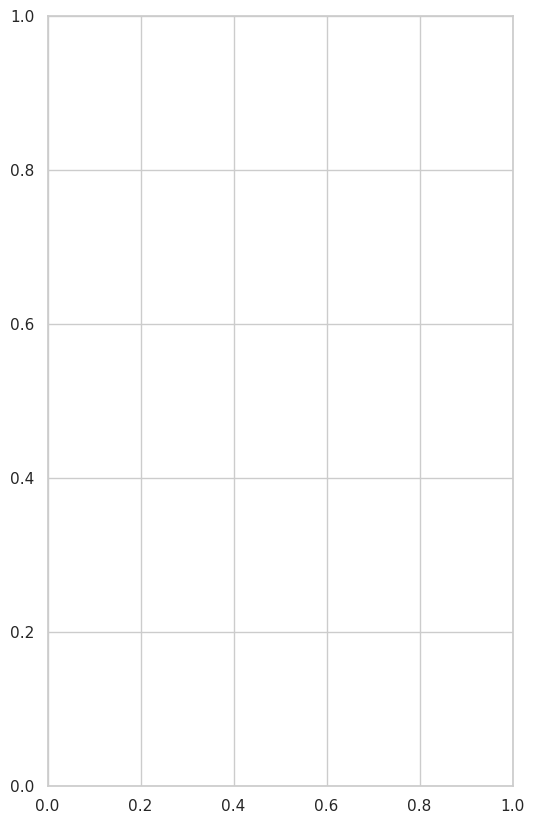

In [23]:


feature_cols = use_cols_new_unique[3:]
colour_dict = get_hard_code_plate_colours(
    combined_cell_df_mitolyso2, ["1", "2", "3", "4", "5", "6", "7"], "Metadata_PlateNumber"
)
def plot_boxplots_with_swarm(display_df, display_df_pivot_plates, feature_cols, colour_dict=colour_dict, size=(6, 10)):
    outpath = "segmentation_test/plots"
    os.makedirs(outpath, exist_ok=True)
    for col in feature_cols:
        plt.figure(figsize=size)
        sns.set_style("whitegrid")
        sns.set_context("notebook")
        sns.boxplot(display_df, x="AllGroups", y=col, palette="pastel" , fill=True, hue="AllGroups", legend=False)
        sns.swarmplot(display_df_pivot_plates, x="AllGroups", y=col, palette=colour_dict,hue="Metadata_PlateNumber", dodge=False, size = 9, legend=False, linewidth=1, edgecolor="k" )
        sns.despine()
        plt.ylim(0, np.percentile(display_df[col].dropna(), 99)*1.1)  
        plt.tight_layout()
        plt.savefig(os.path.join(outpath, f"{col}_boxplot.png"))
        plt.show()
        
# def plot_boxplots_with_swarm_pairs(
#     display_df,
#     display_df_pivot_plates,
#     feature_cols,
#     colour_dict=colour_dict,
#     size=(6, 10),
# ):
#     outpath = "segmentation_test/pairedplots"
#     os.makedirs(outpath, exist_ok=True)
#     for col in feature_cols:
#         fig, axes = plt.subplots(1, 2, figsize=(figsize[0] * 2, figsize[1]), sharey=True)

#         for ax, suffix in zip(axes, ["1", "2"]):
#             item = rows[suffix]
#         sns.set_style("whitegrid")
#         sns.set_context("notebook")
#         ax = plt.gca()
#         ax = sns.boxplot(
#             display_df,
#             x="AllGroups",
#             y=col,
#             palette="pastel",
#             fill=True,
#             hue="AllGroups",
#             legend=False,
#         )
#         sns.swarmplot(
#             display_df_pivot_plates,
#             x="AllGroups",
#             y=col,
#             palette=colour_dict,
#             hue="Metadata_PlateNumber",
#             dodge=False,
#             size=9,
#             legend=False,
#             linewidth=1,
#             edgecolor="k",
#         )
#         sns.despine()
#         plt.ylim(0, np.percentile(display_df[col].dropna(), 99) * 1.1)
#         plt.tight_layout()
#         plt.savefig(os.path.join(outpath, f"{col}_boxplot.png"))
#         plt.show()

plot_boxplots_with_swarm(display_df, display_df_pivot_plates, feature_cols, colour_dict, size=(6, 10))

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:1.400e-02


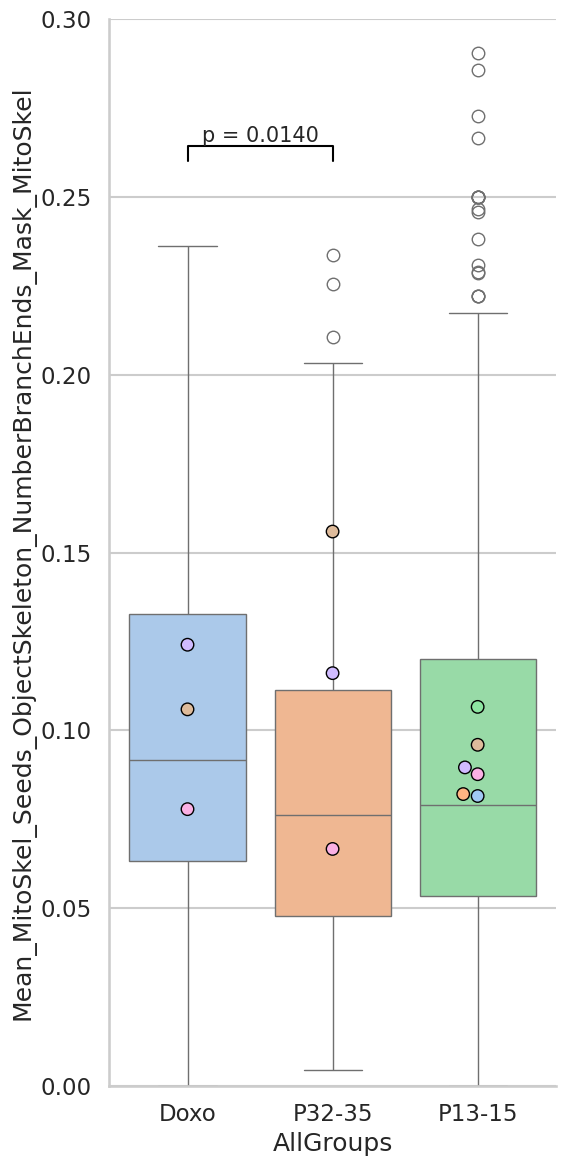

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:9.900e-03


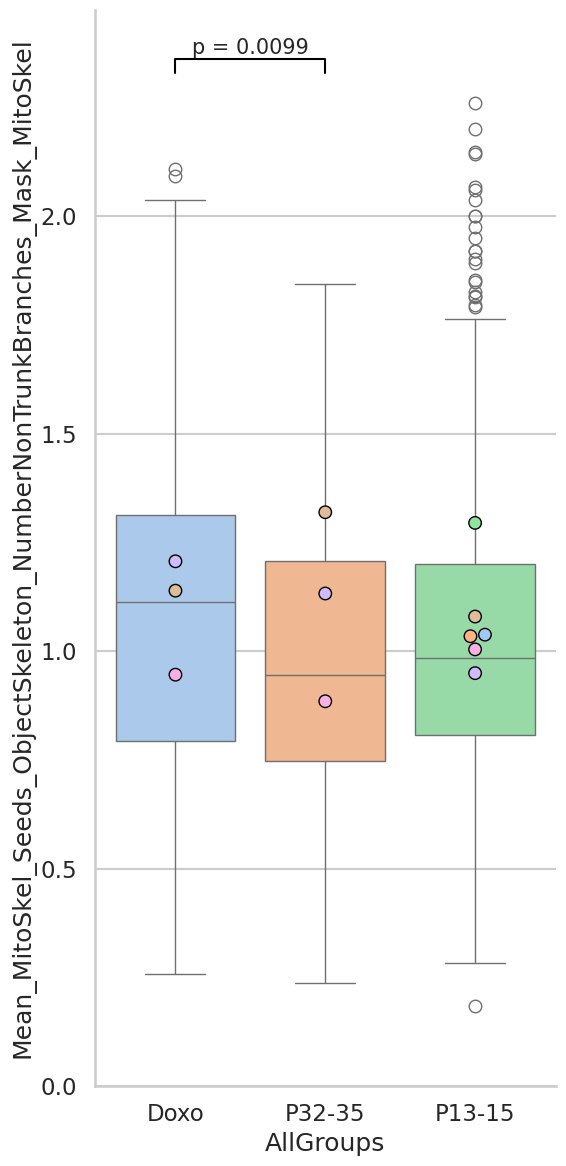

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261


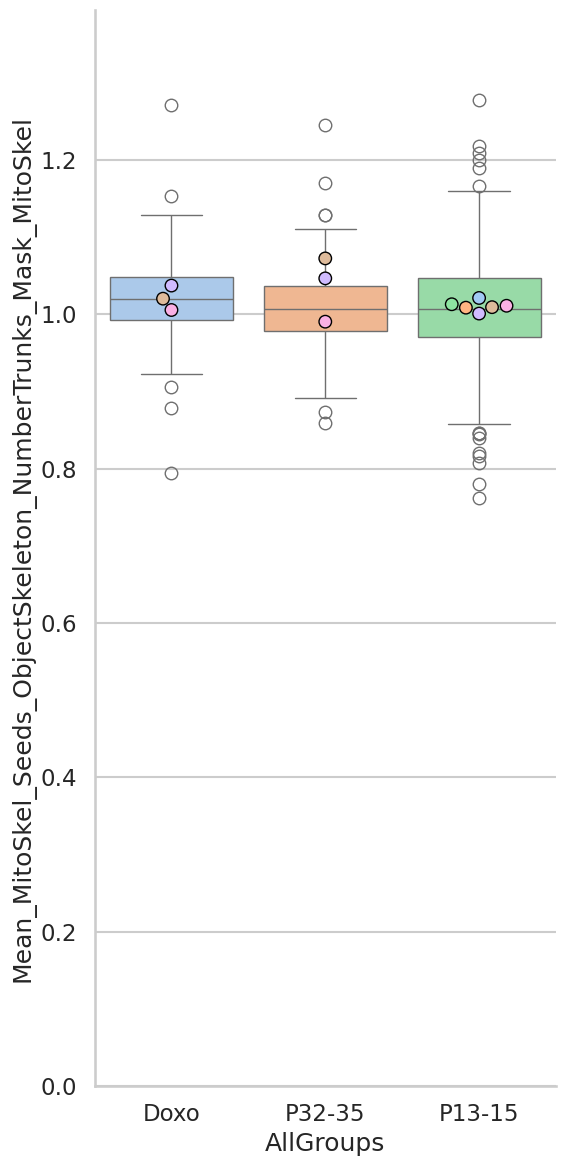

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:5.400e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:5.300e-03


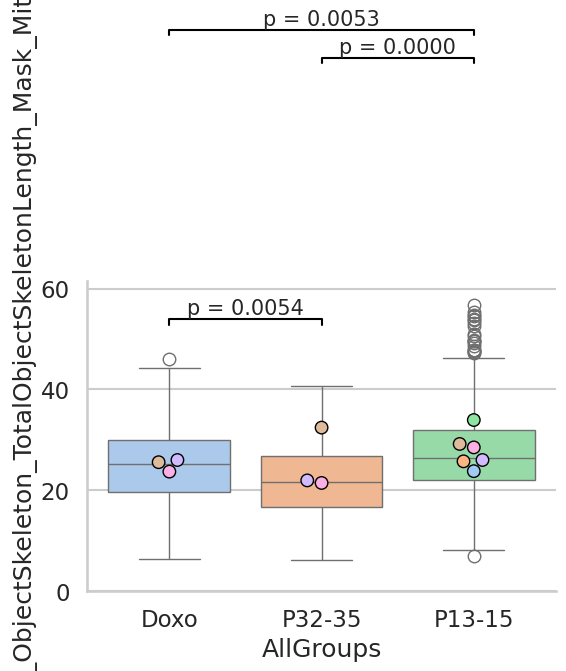

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


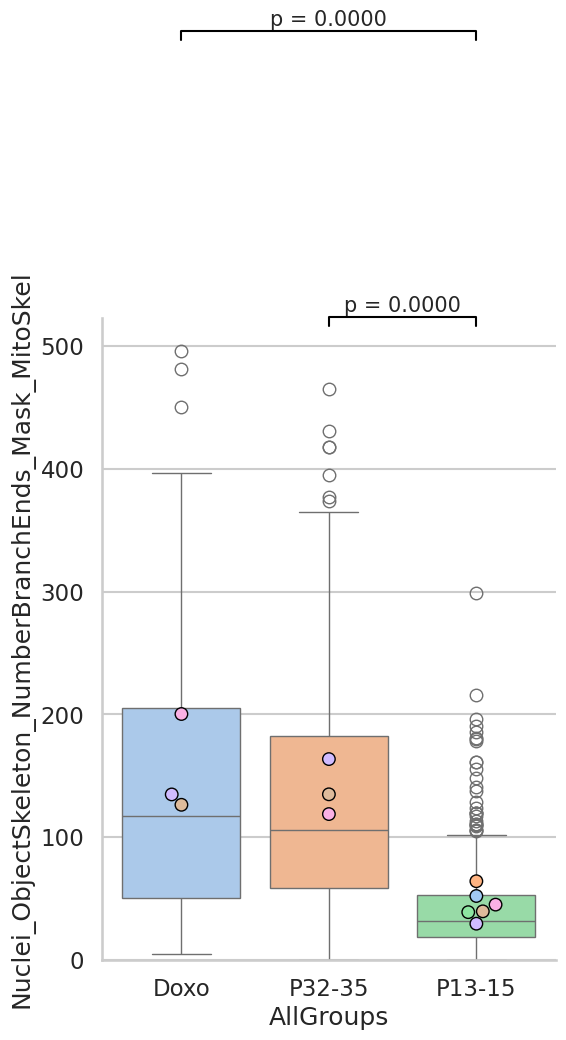

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


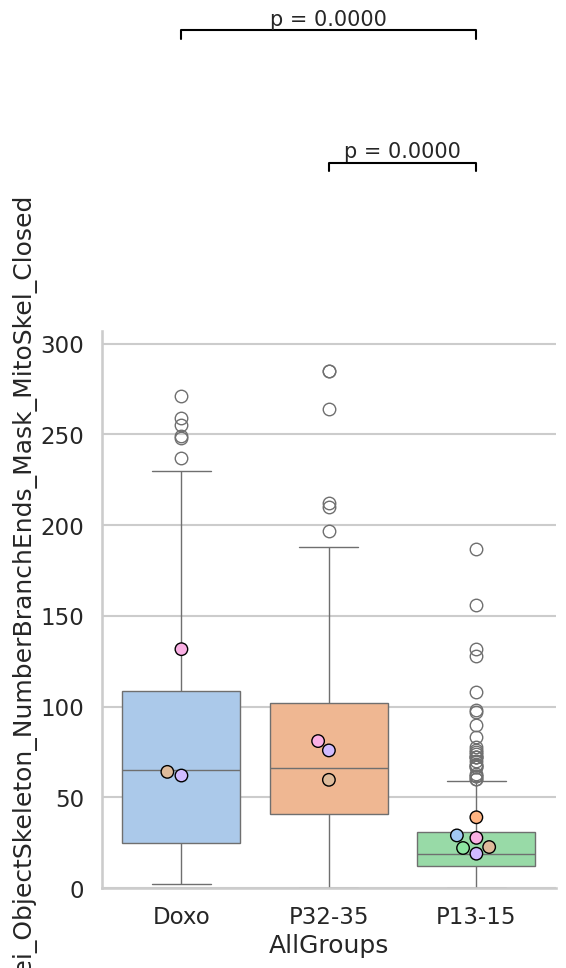

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:2.530e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


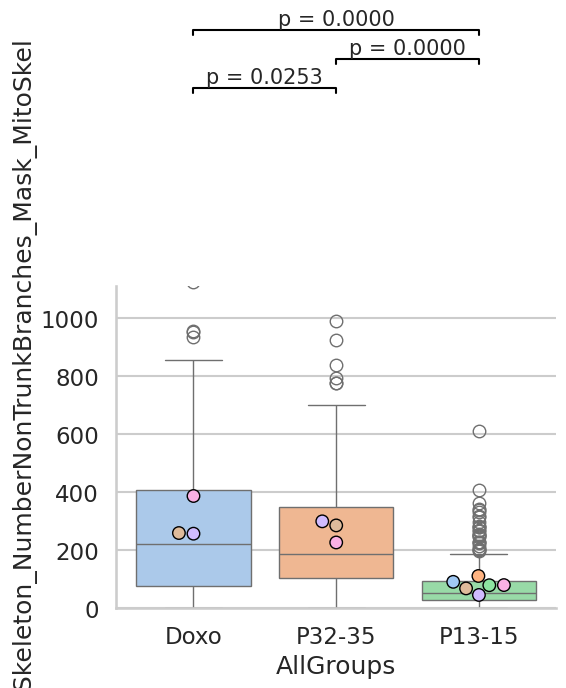

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


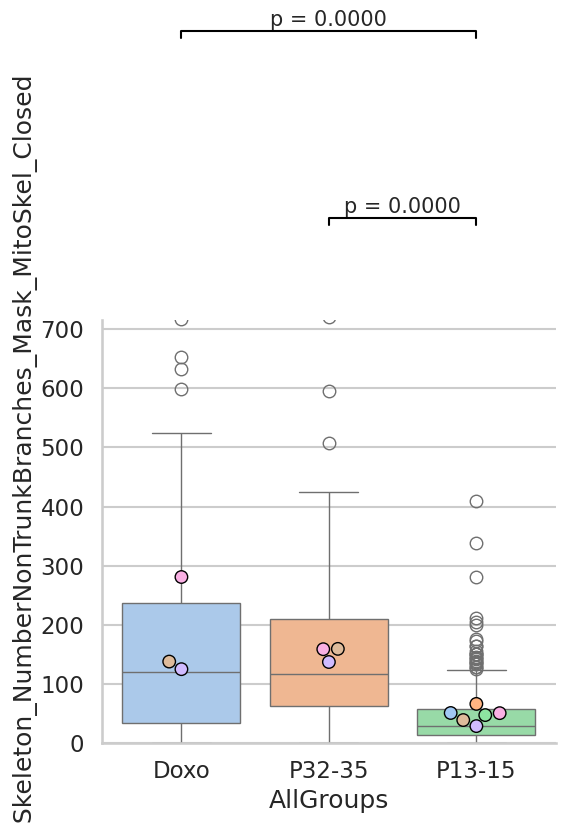

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


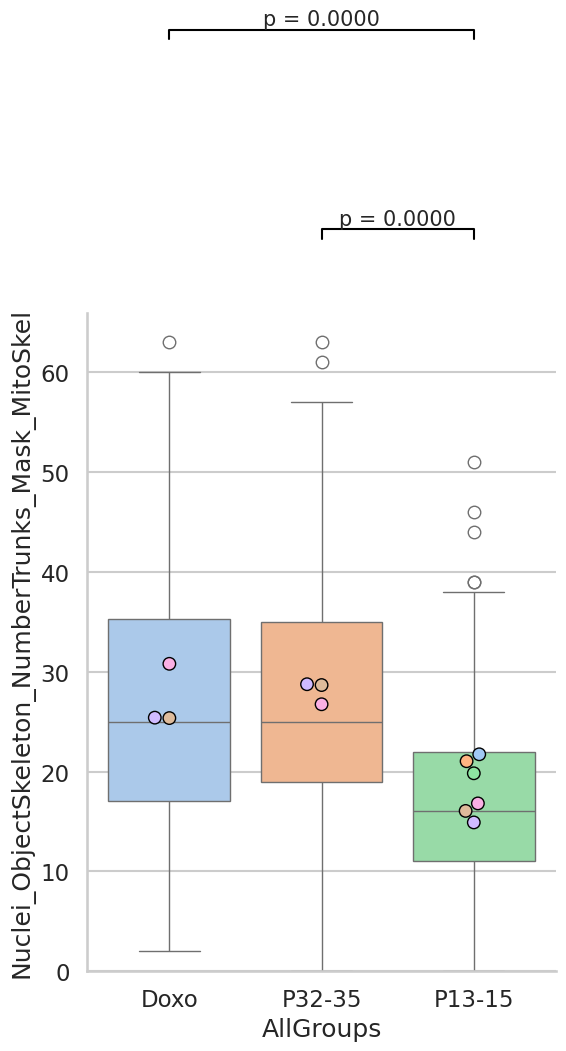

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


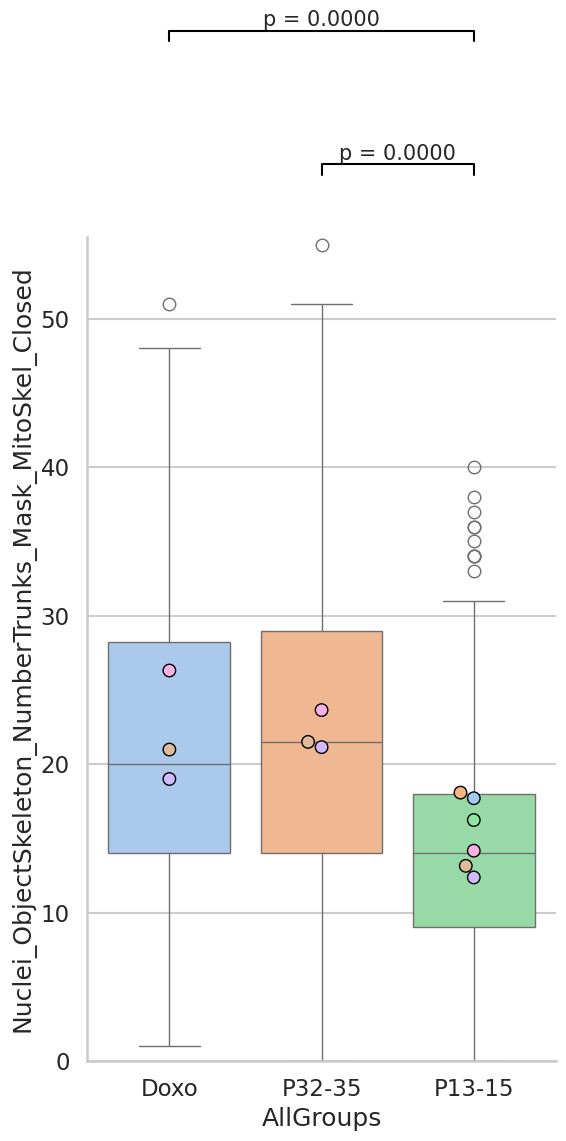

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:9.800e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


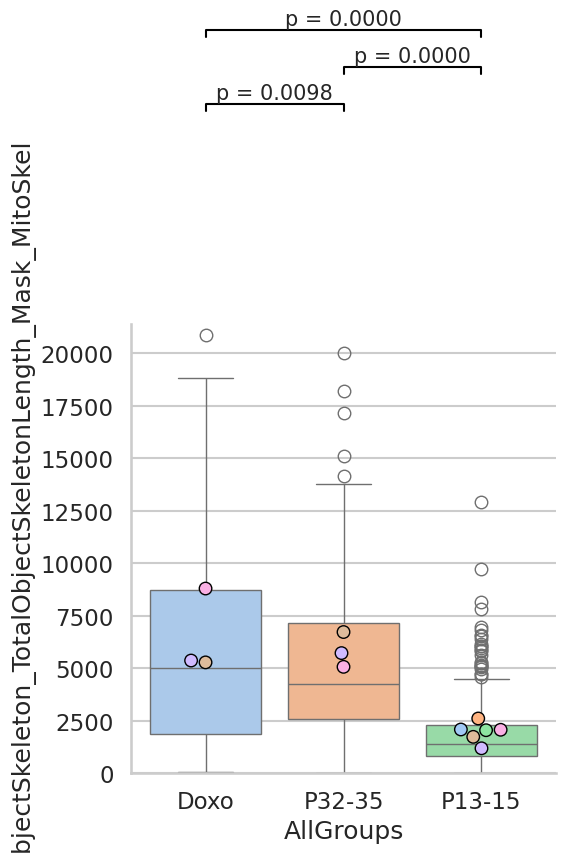

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.830e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


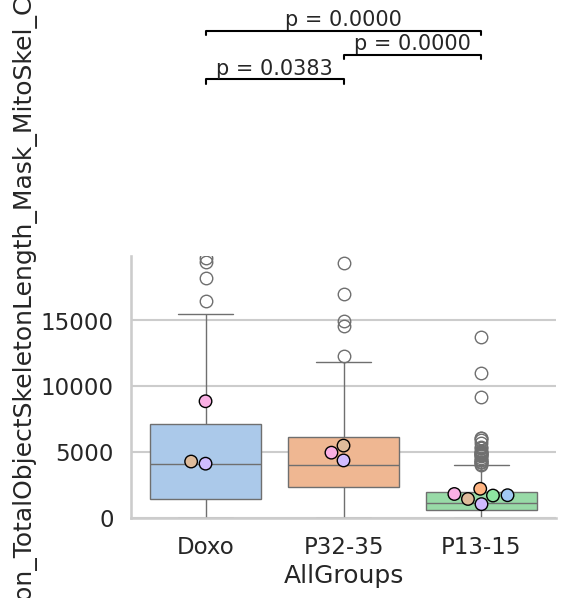

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.360e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


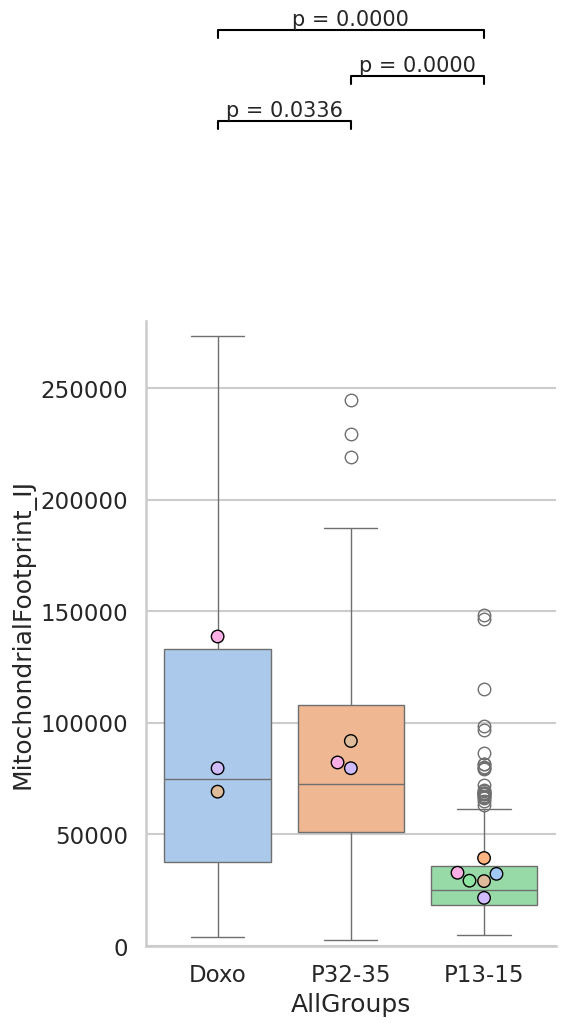

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


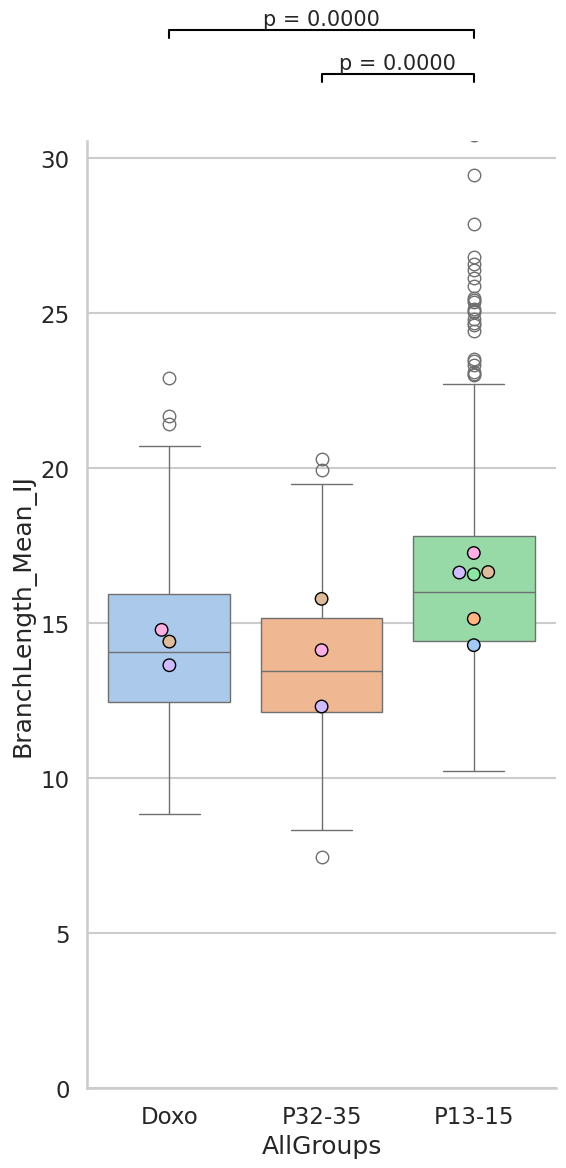

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


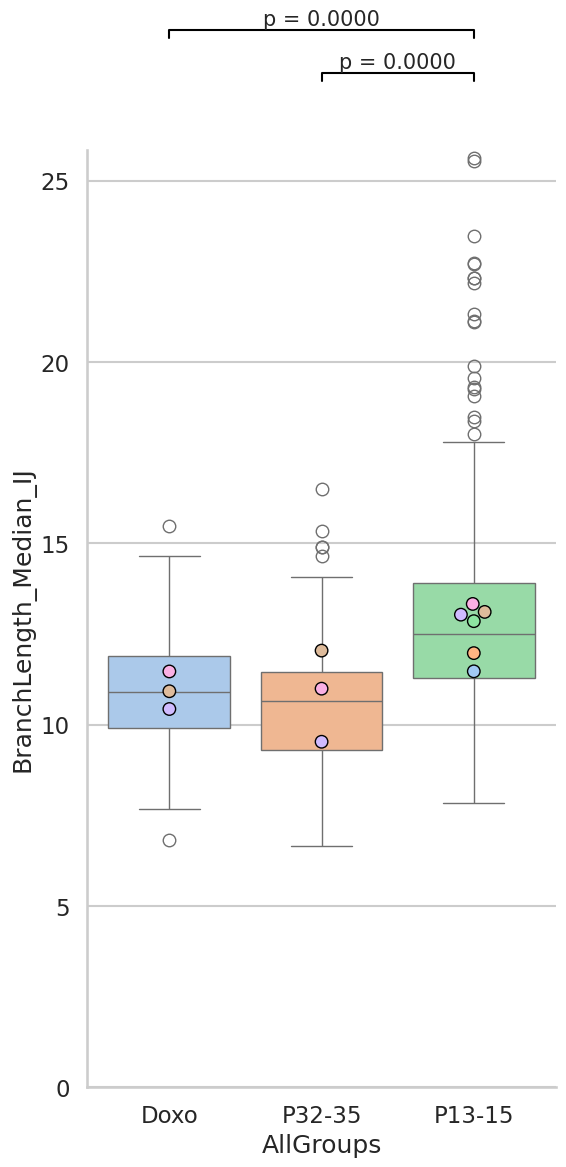

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:2.000e-04


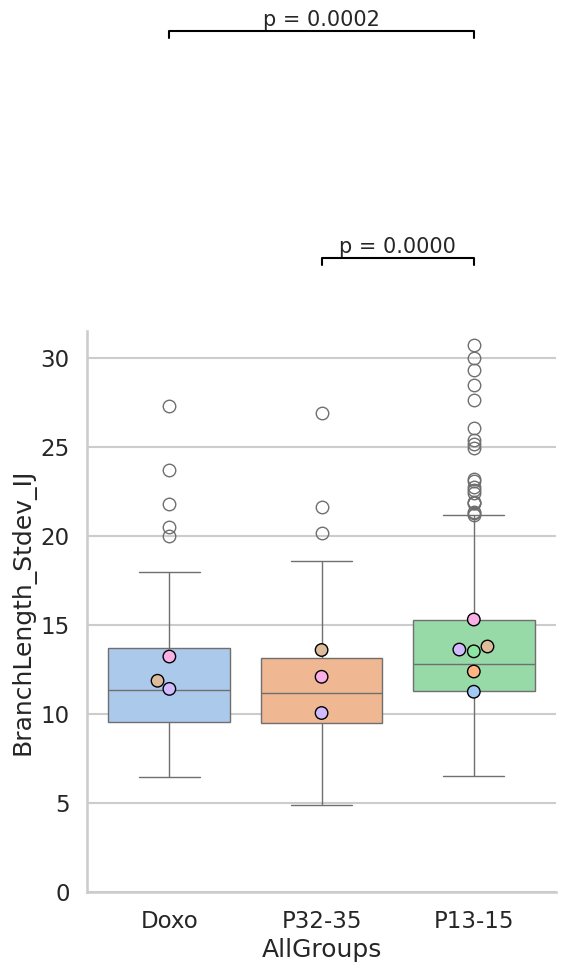

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:9.000e-04
Doxo vs. P13-15: Custom statistical test, P_val:7.300e-03


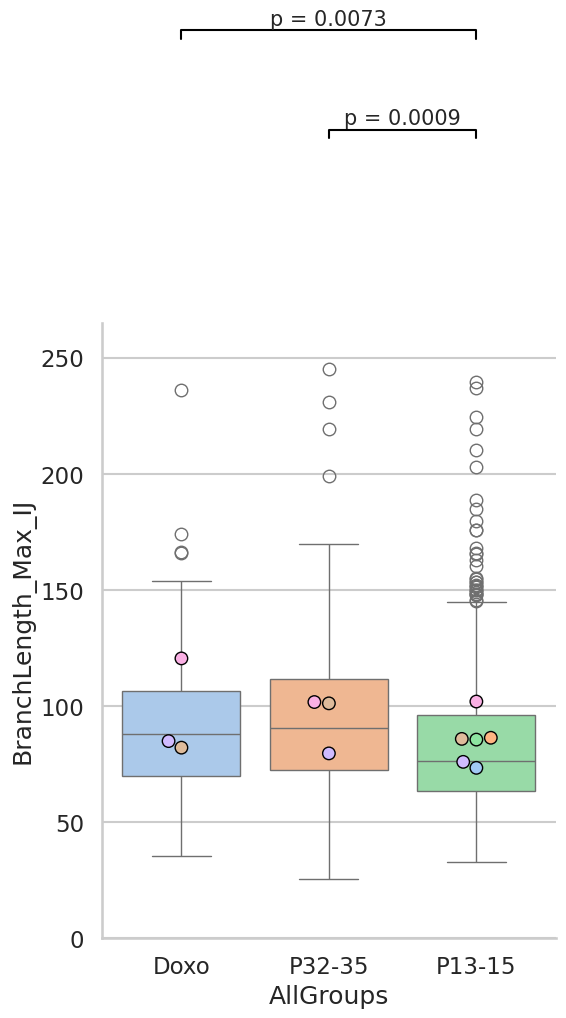

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:2.770e-02


/tmp/ipykernel_3787/899691807.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


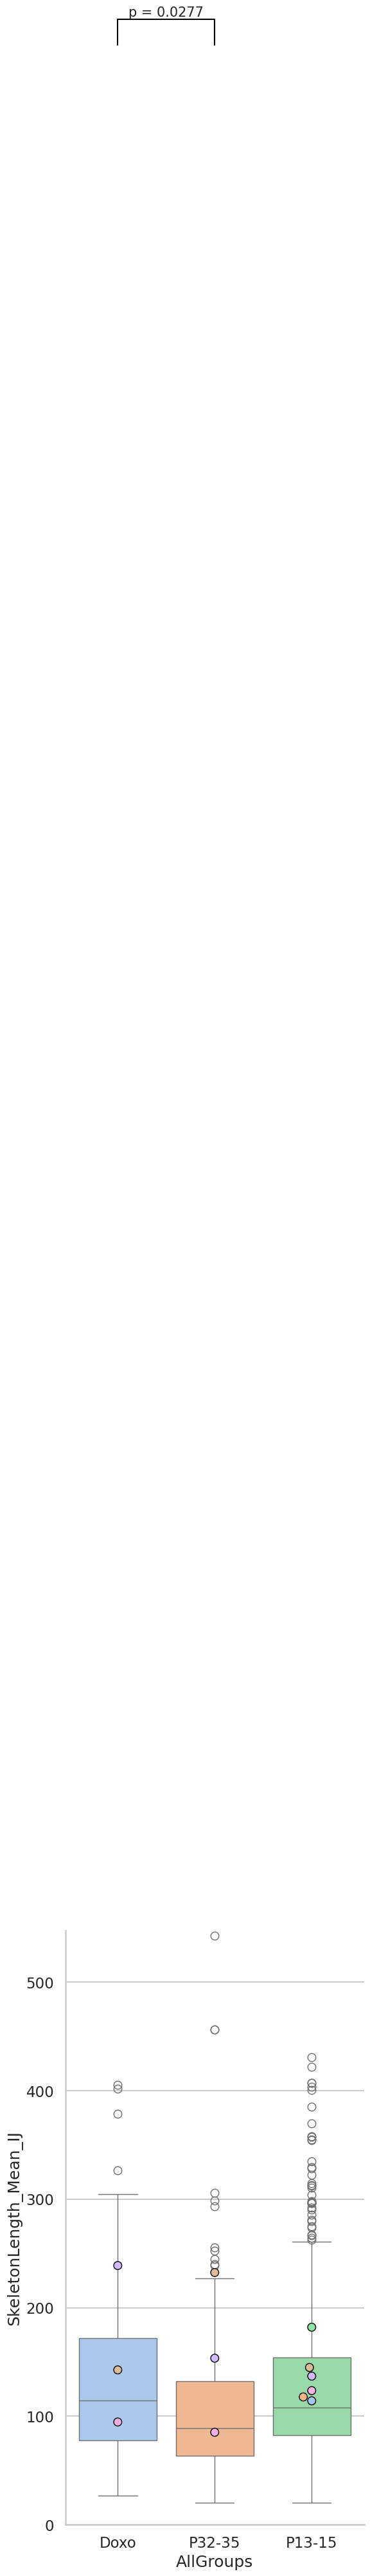

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261


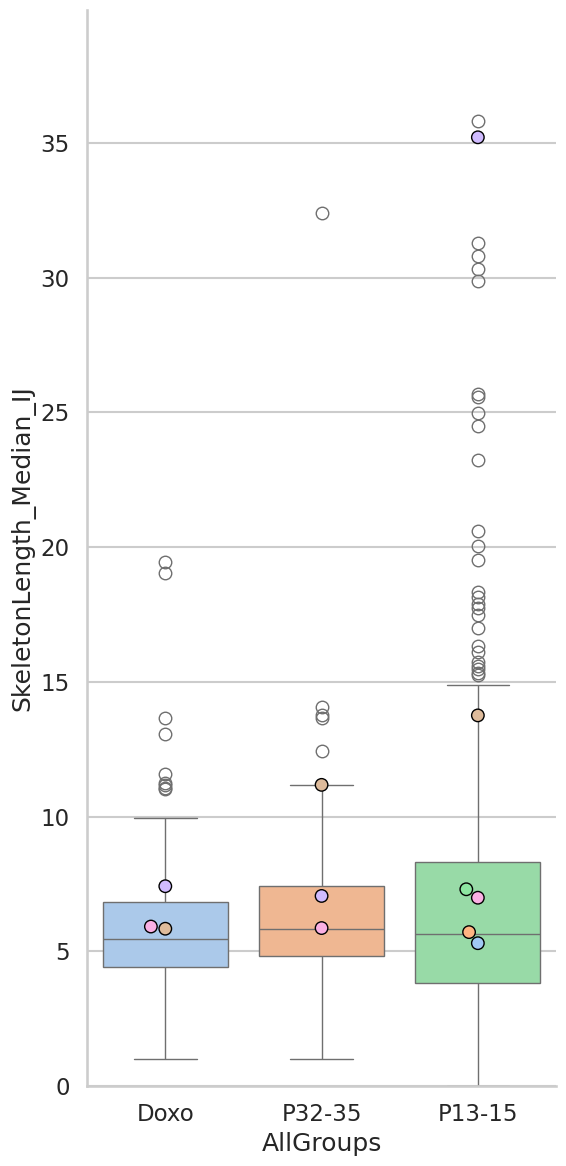

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:0.000e+00
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


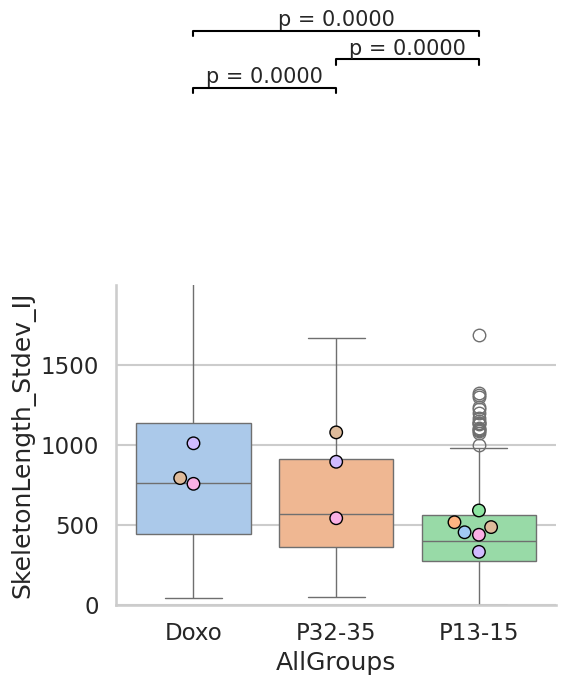

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:8.000e-04
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


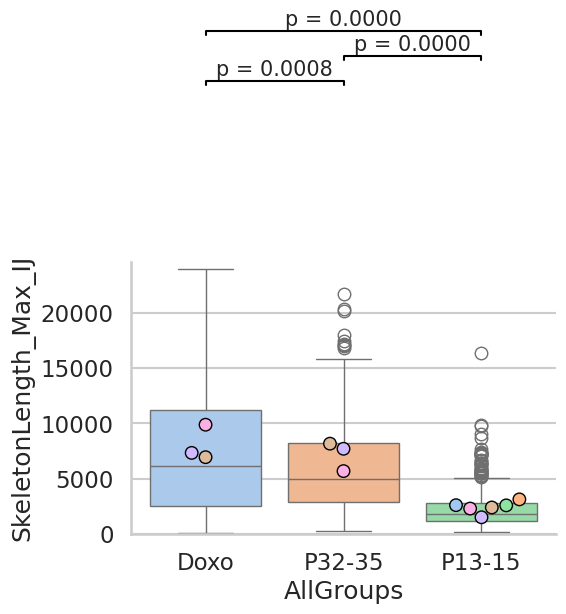

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:2.230e-02
Doxo vs. P13-15: Custom statistical test, P_val:8.500e-03


/tmp/ipykernel_3787/899691807.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


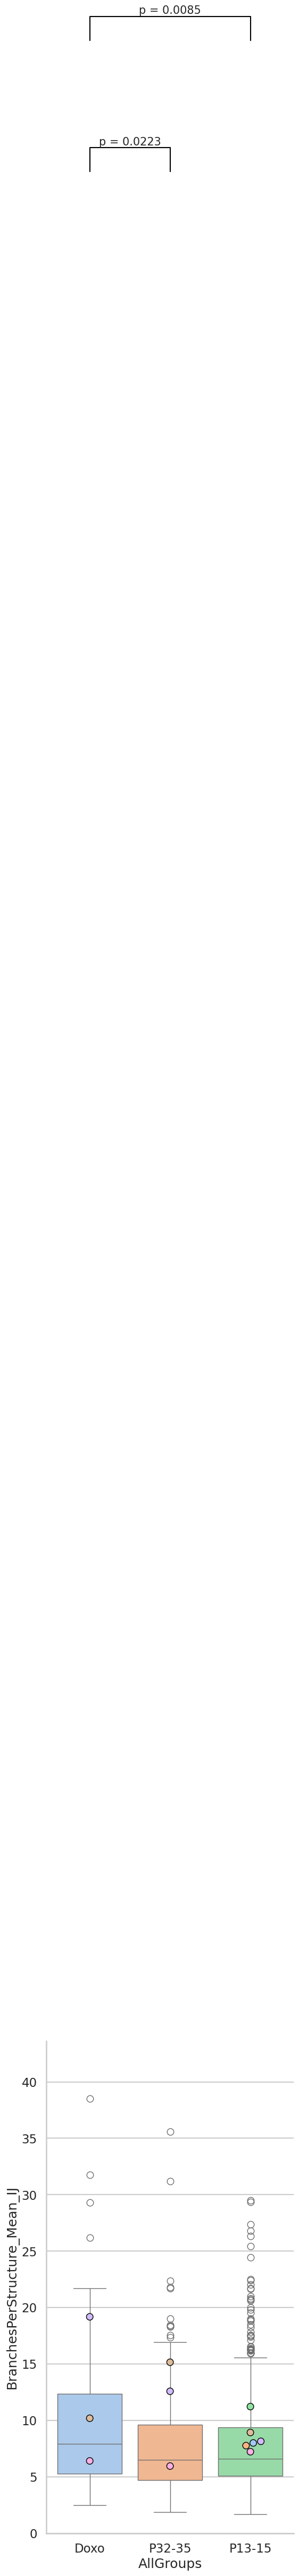

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261


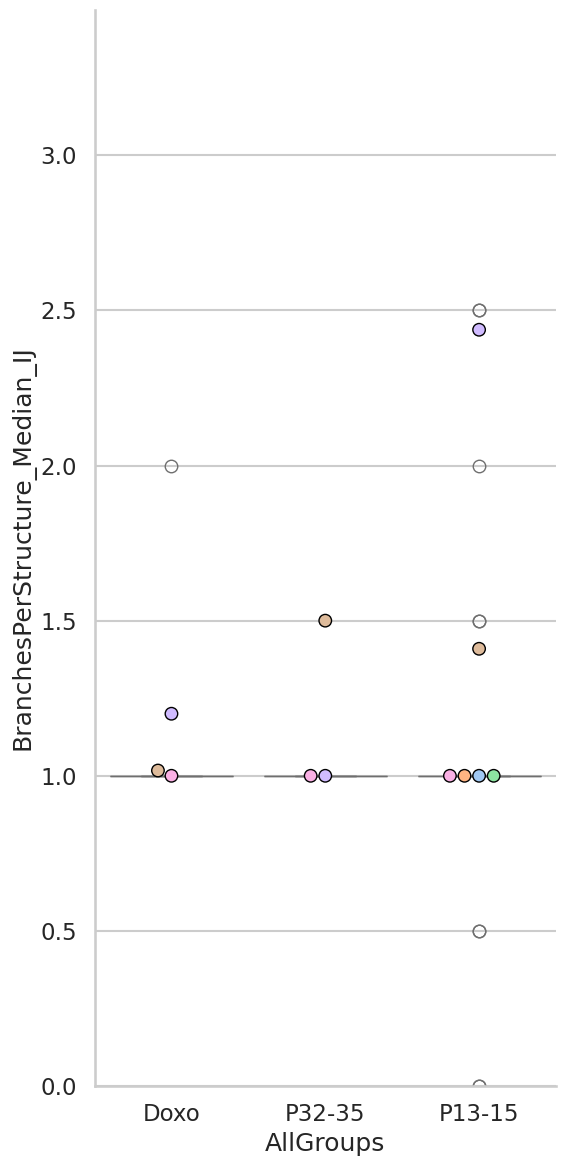

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:4.000e-04
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


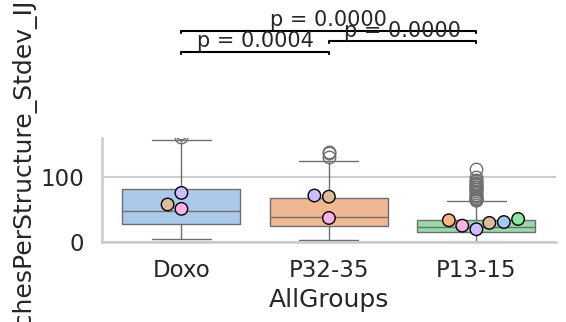

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:4.900e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


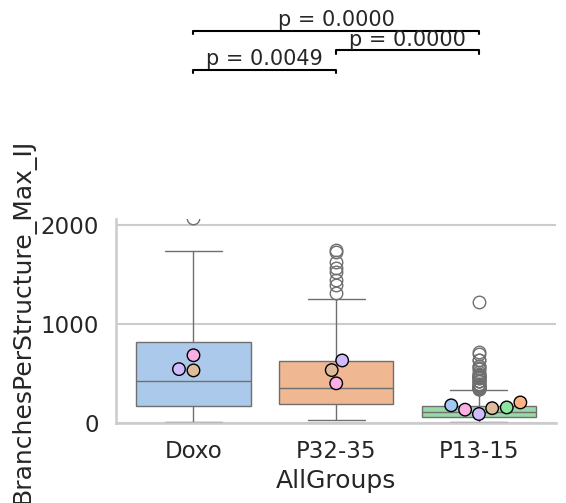

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


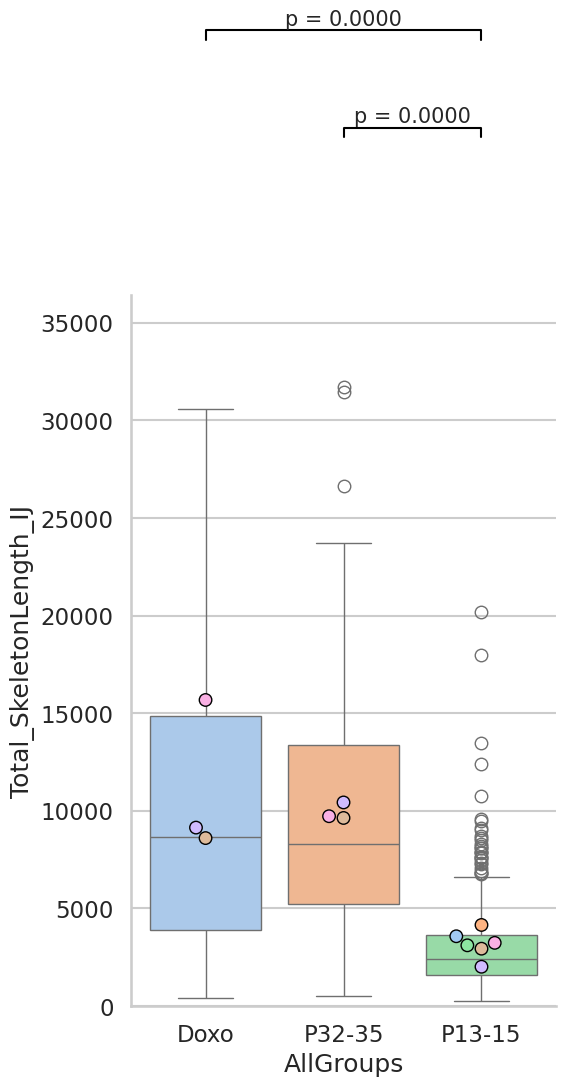

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


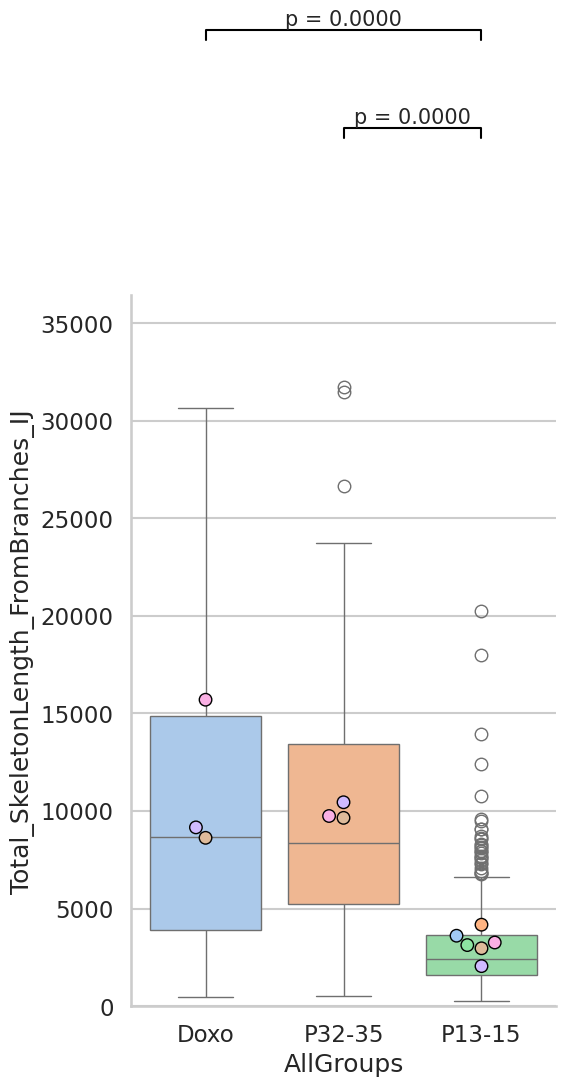

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


/tmp/ipykernel_3787/899691807.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


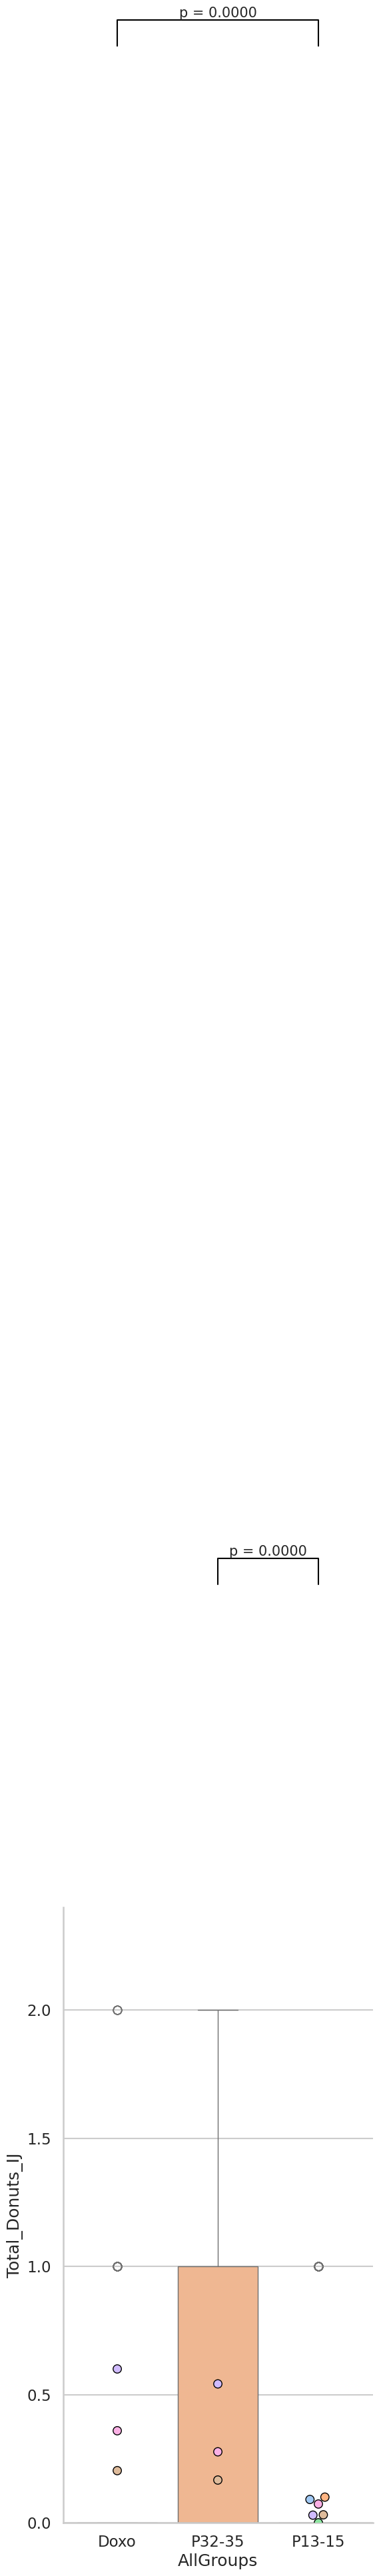

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


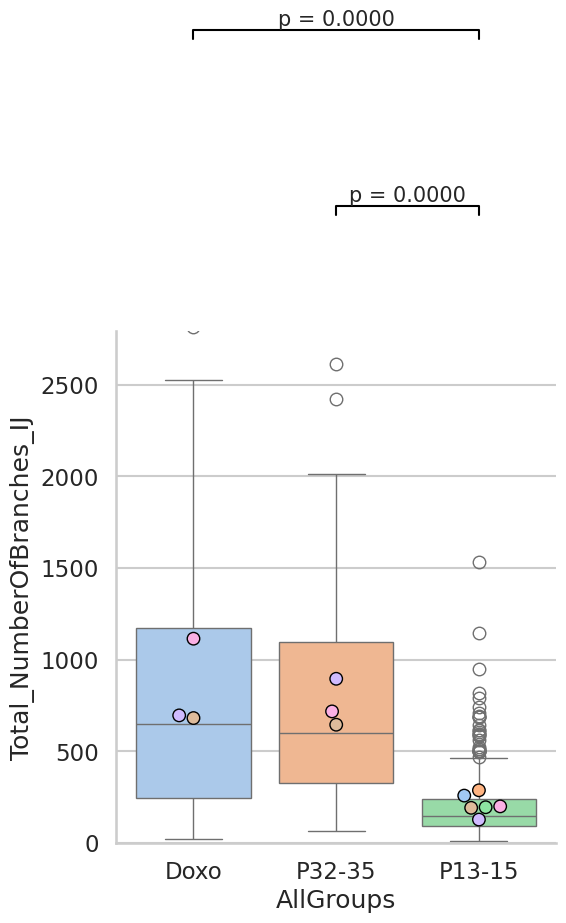

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


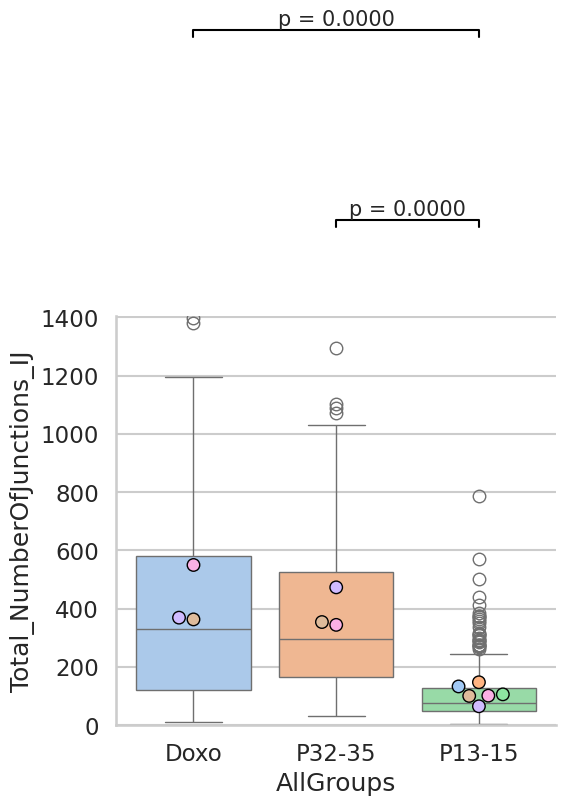

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


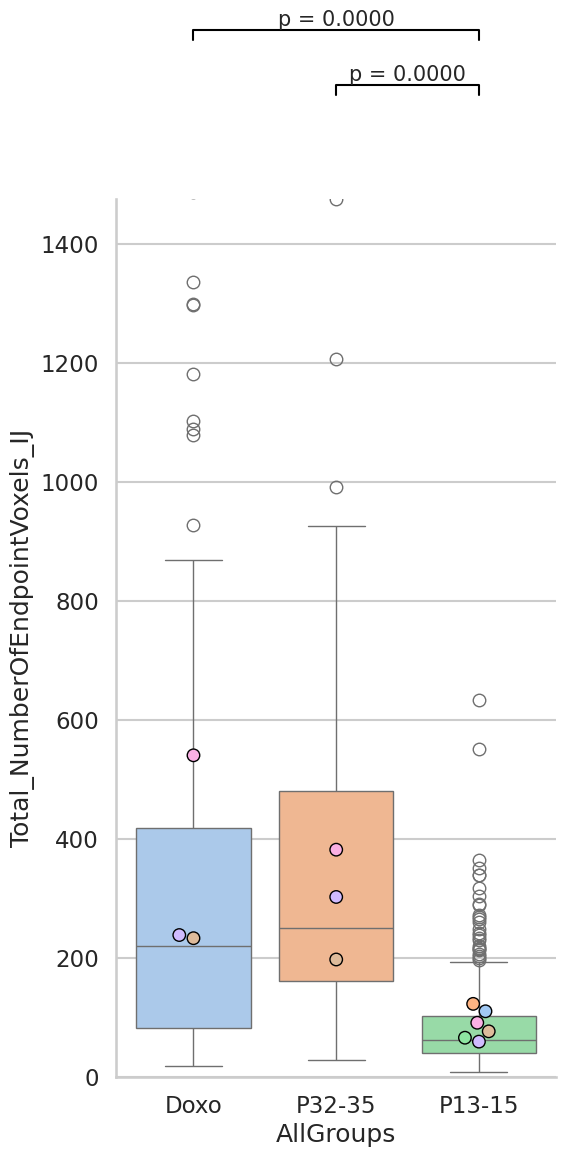

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


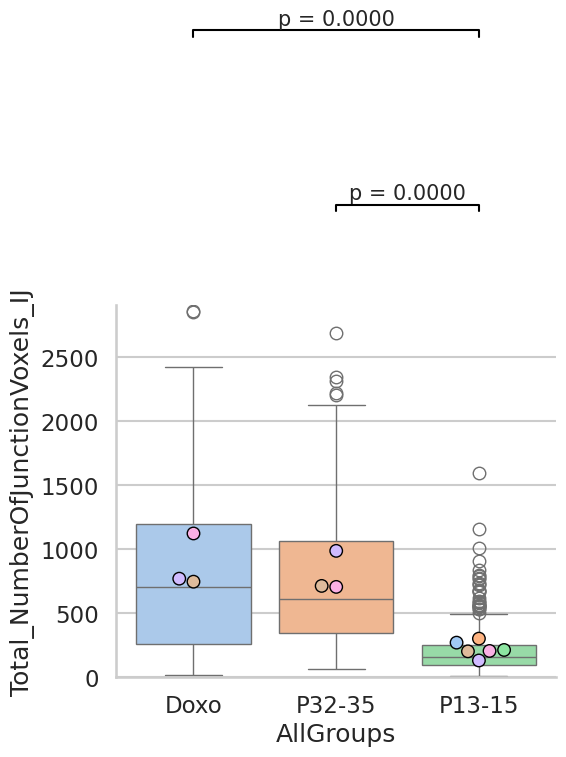

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


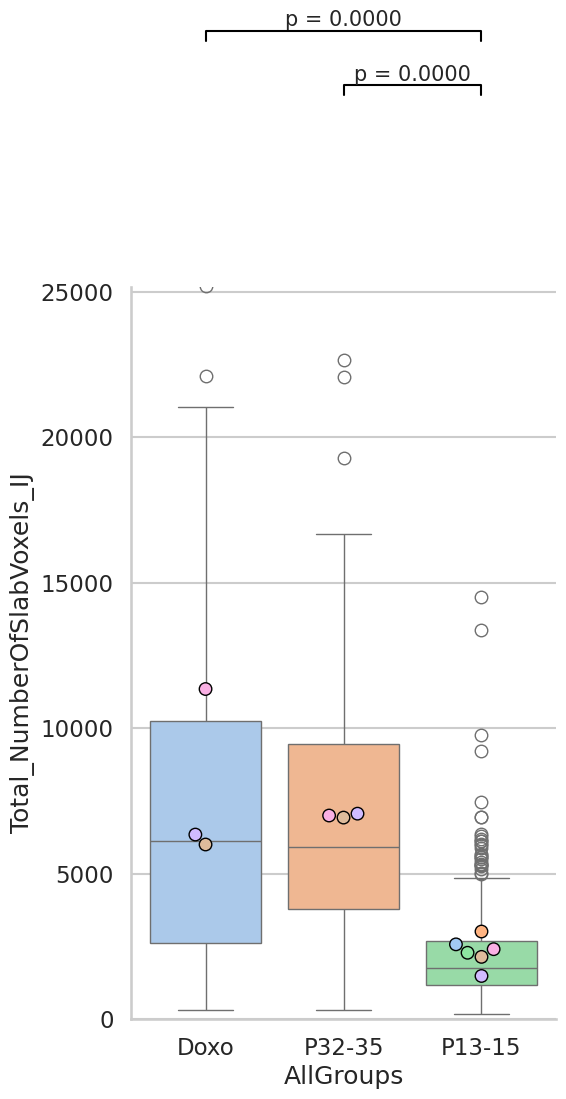

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


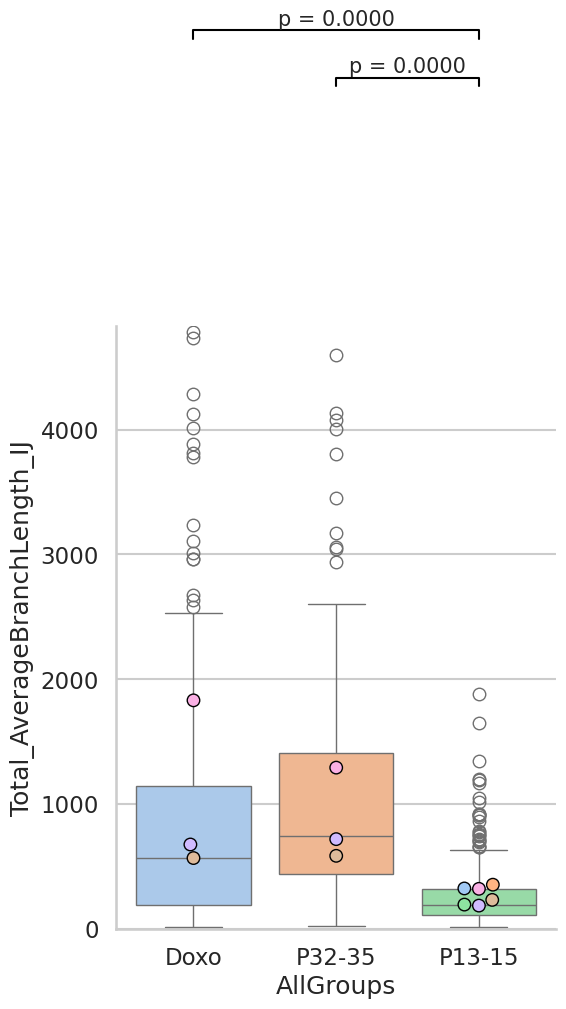

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


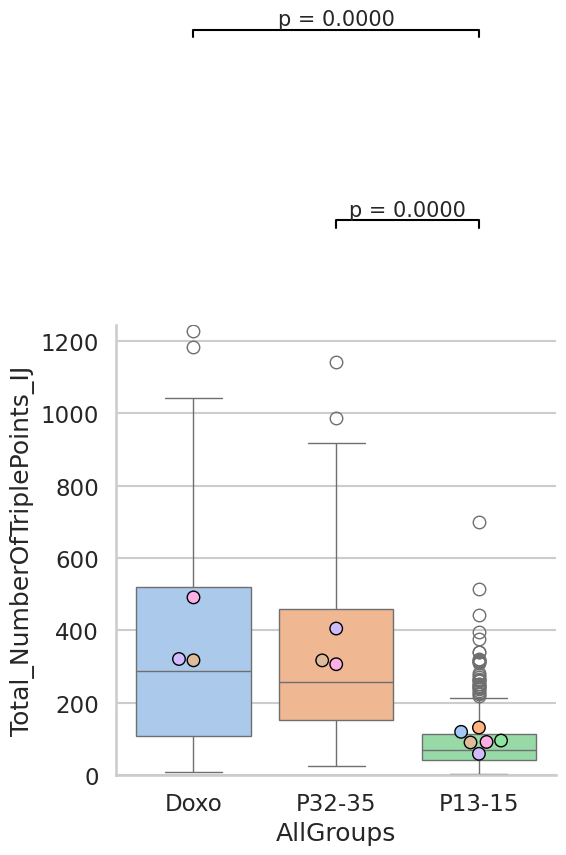

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


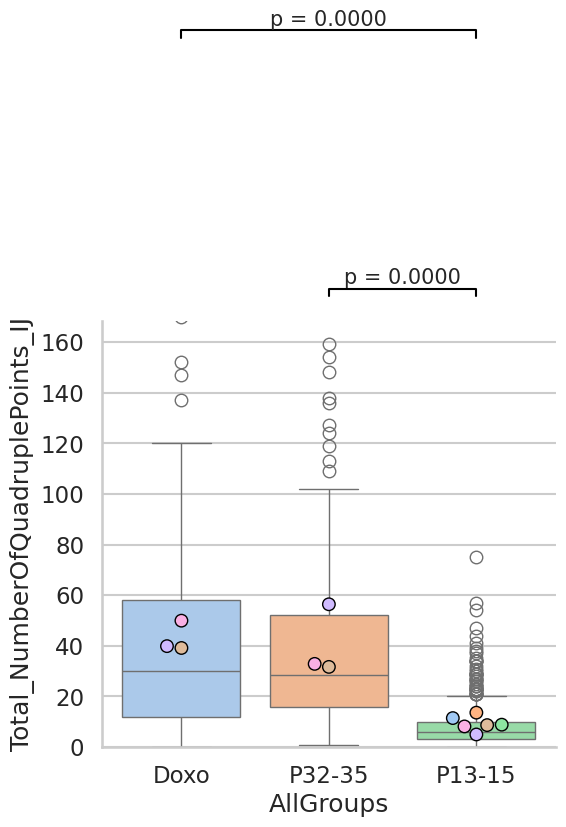

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


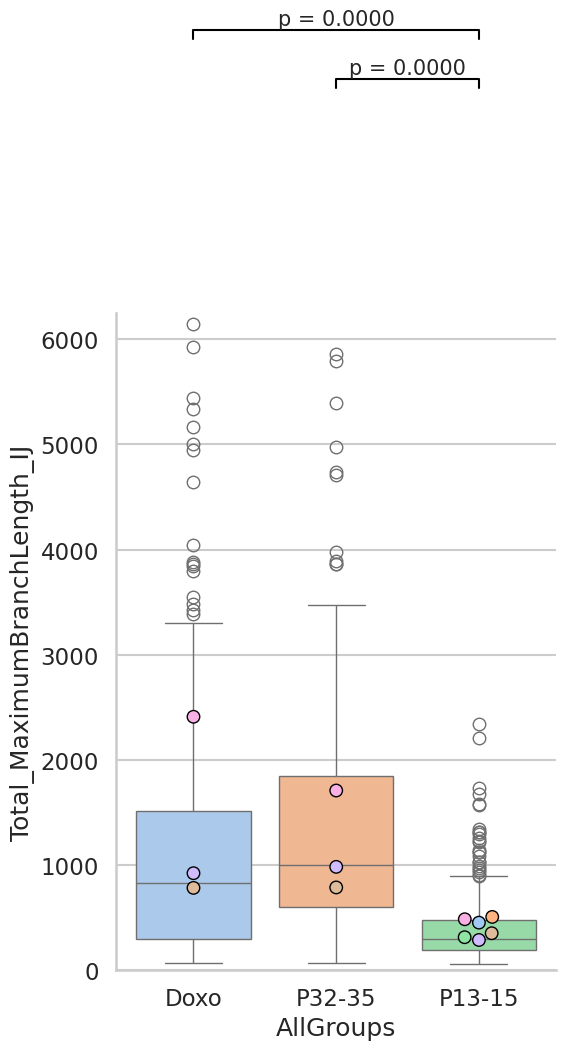

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


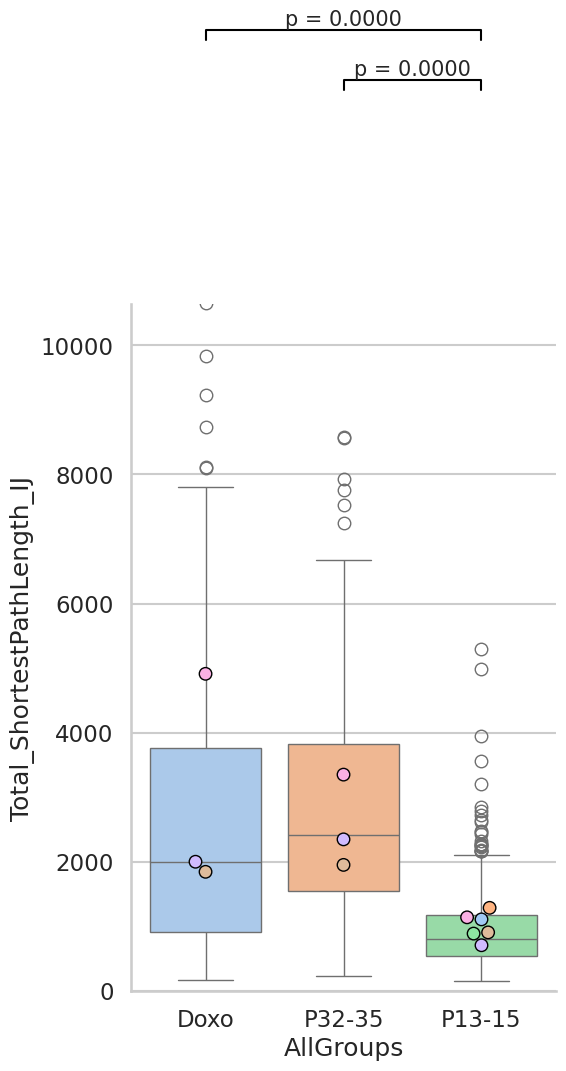

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:4.900e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


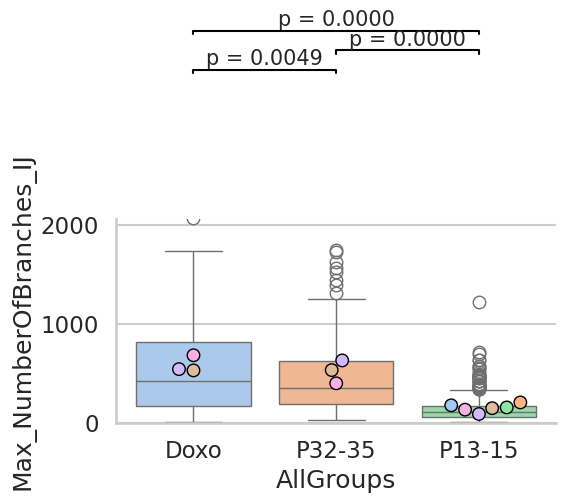

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:4.000e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


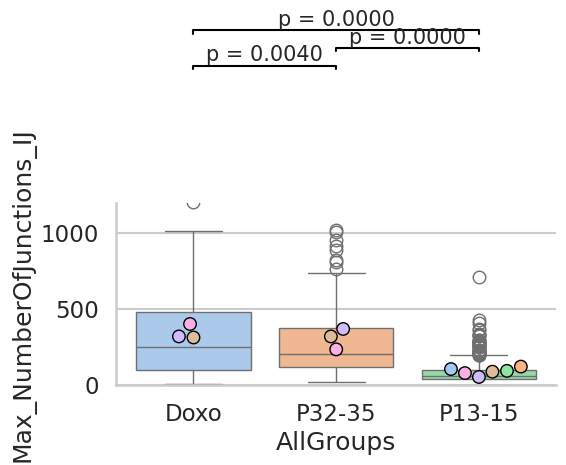

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:2.210e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


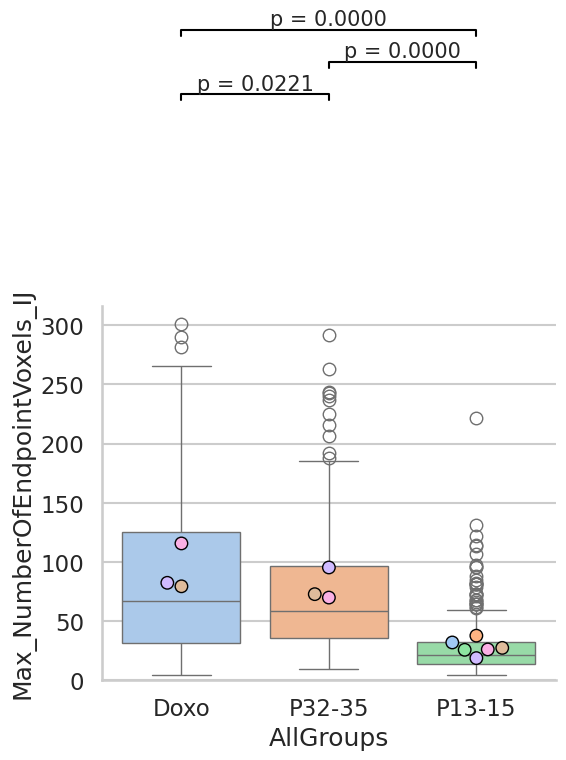

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:4.300e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


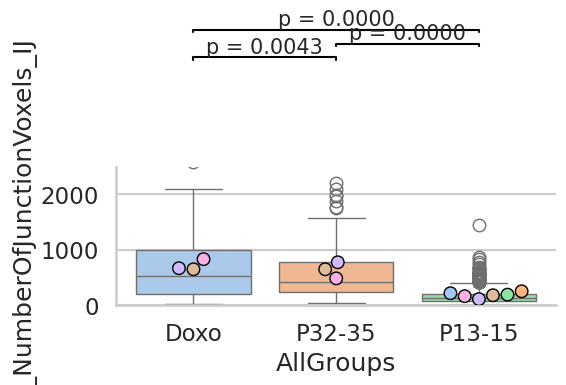

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:6.000e-04
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


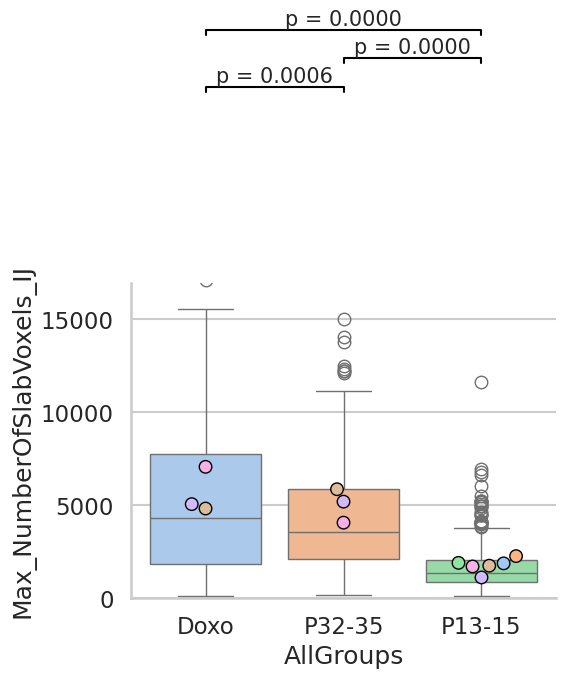

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


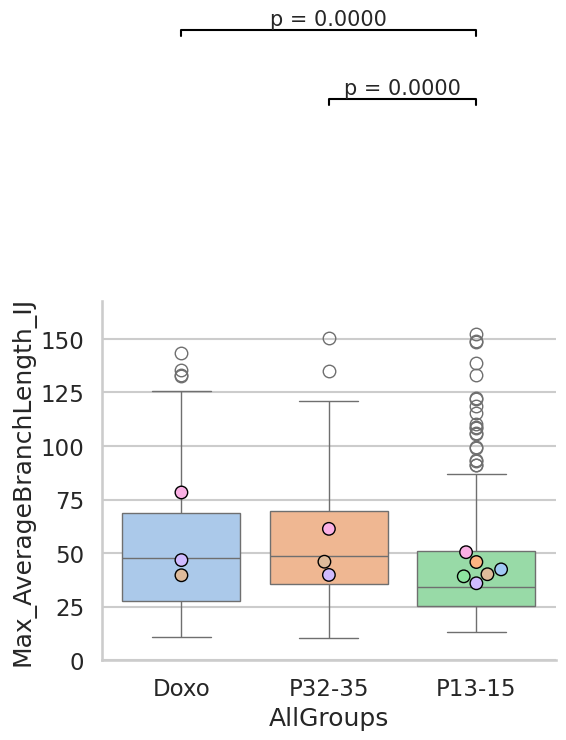

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.200e-03
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


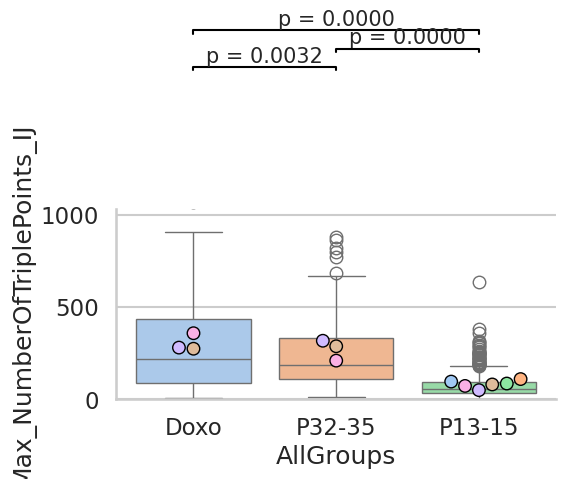

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.600e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


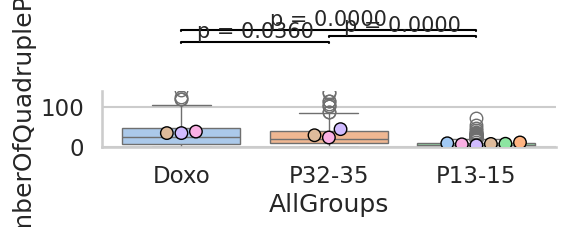

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:9.000e-04
Doxo vs. P13-15: Custom statistical test, P_val:7.300e-03


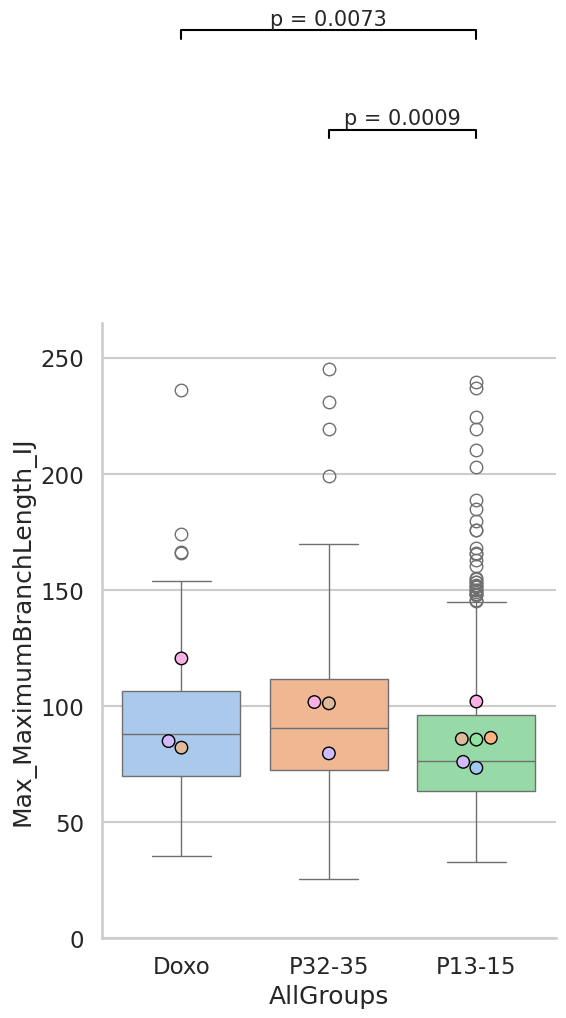

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


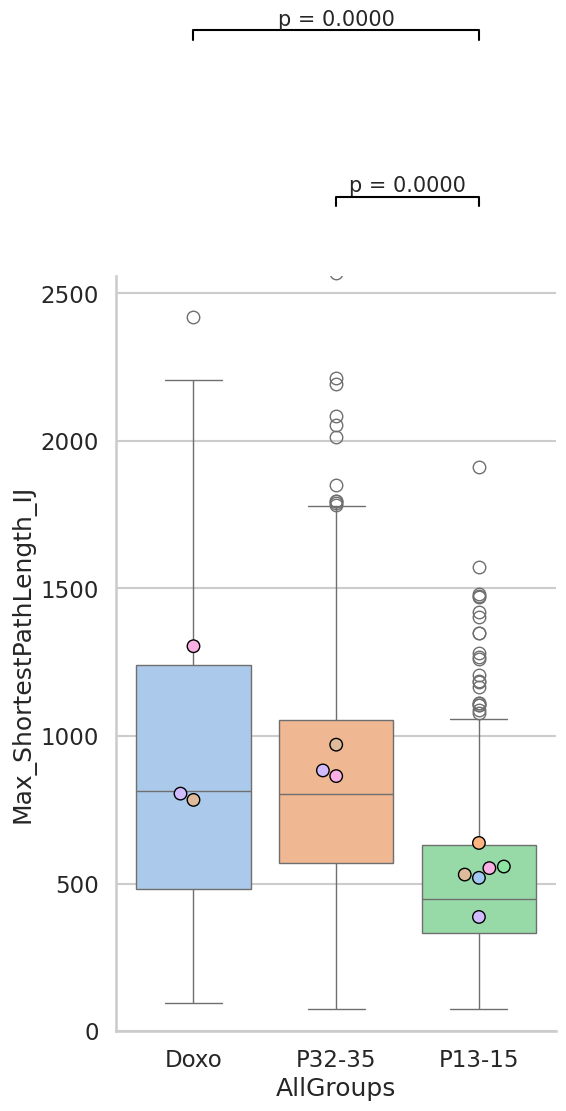

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


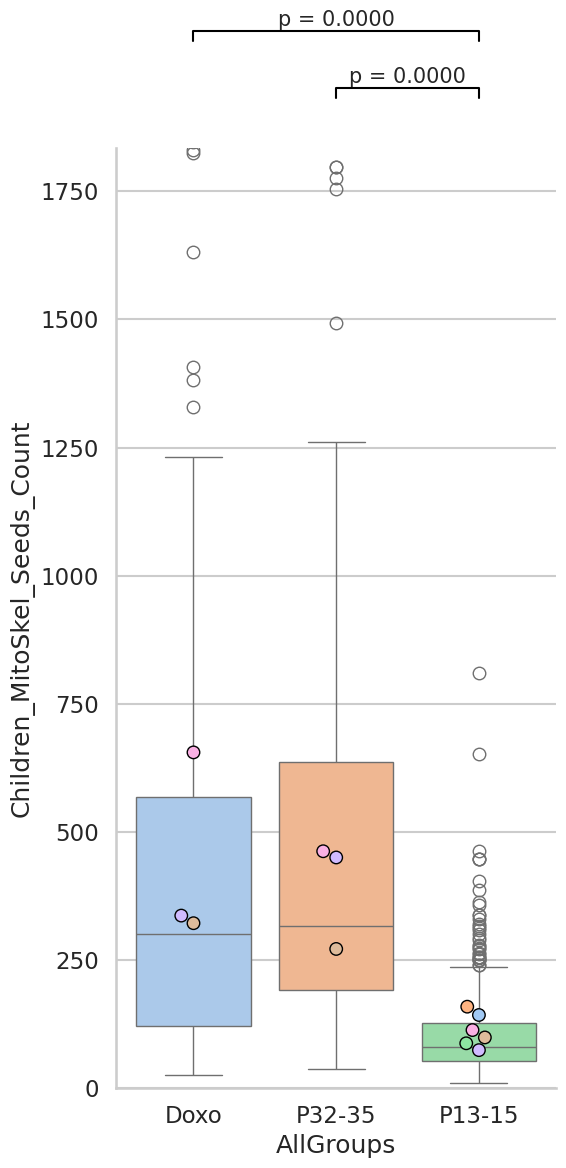

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


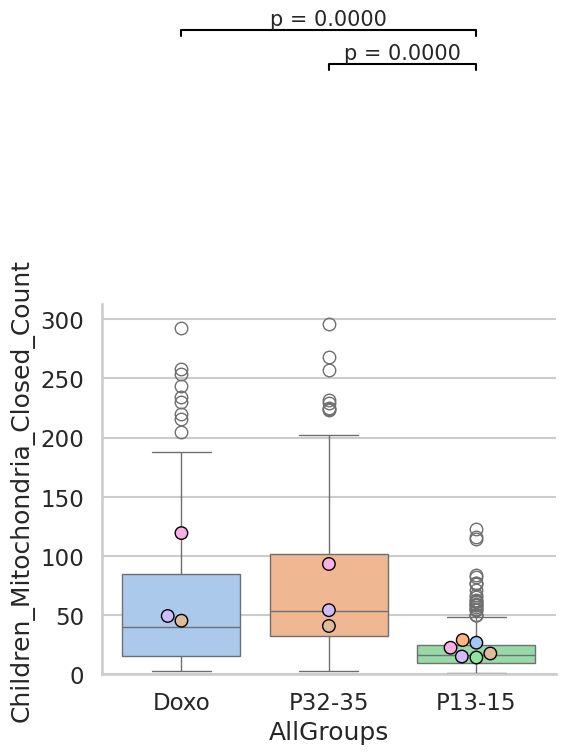

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


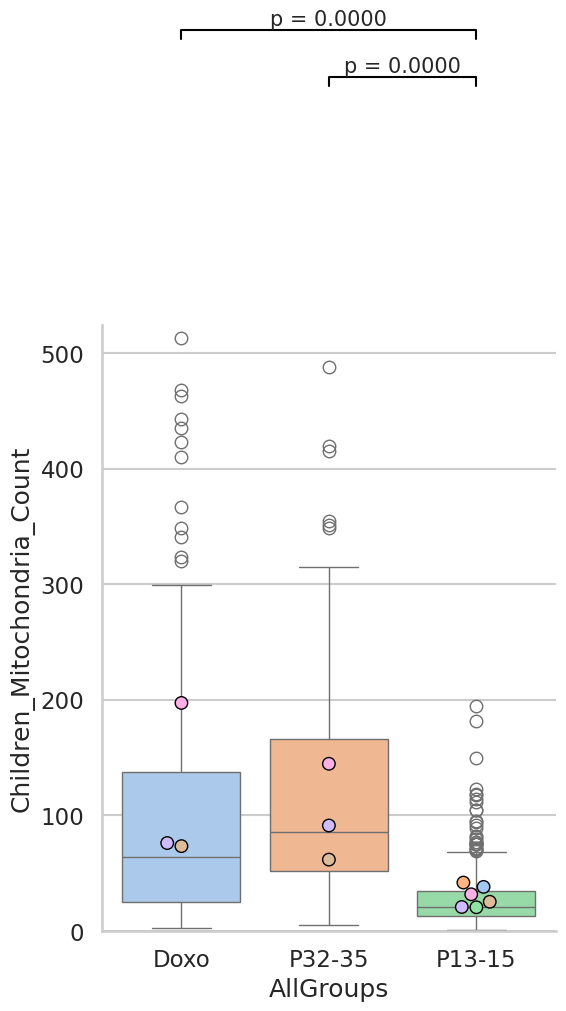

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
P32-35 vs. P13-15: Custom statistical test, P_val:3.000e-04


/tmp/ipykernel_3787/899691807.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


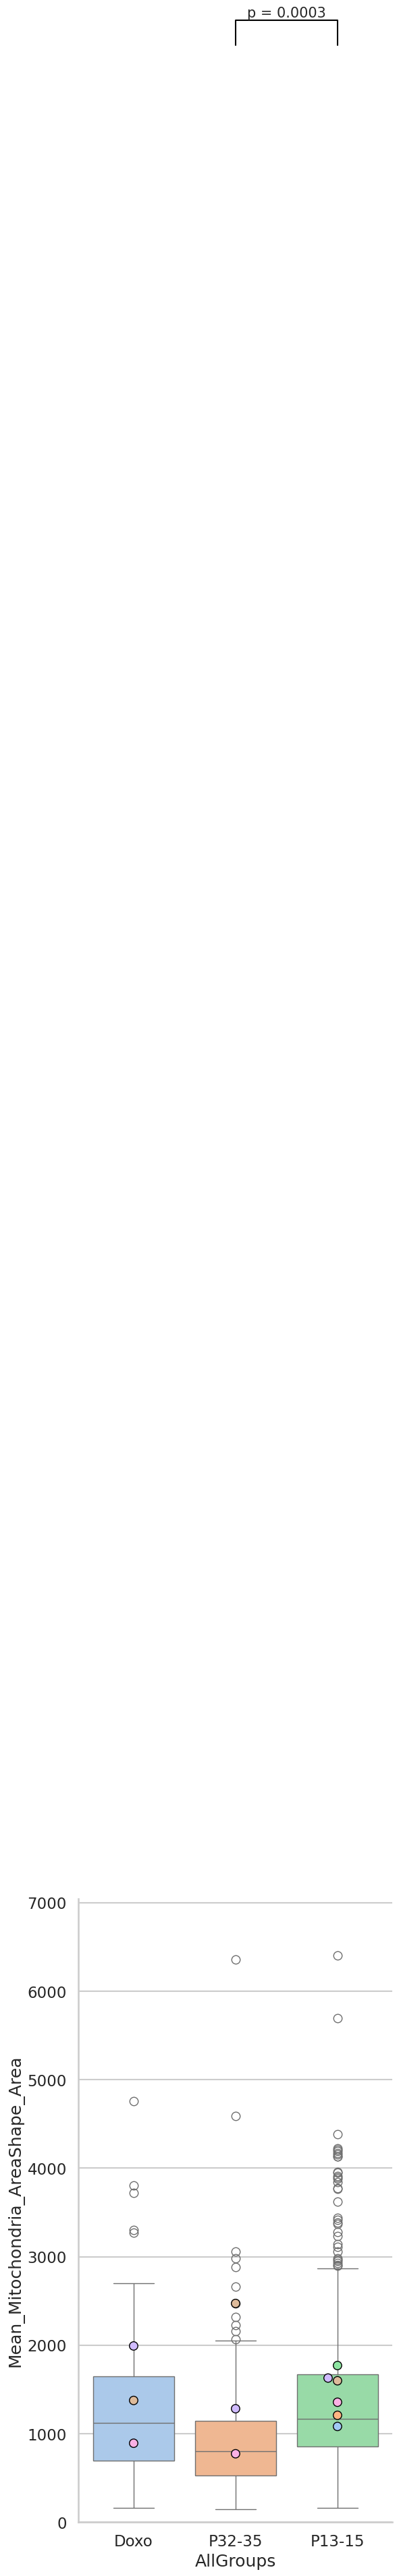

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.910e-02
P32-35 vs. P13-15: Custom statistical test, P_val:7.300e-03


/tmp/ipykernel_3787/899691807.py:86: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


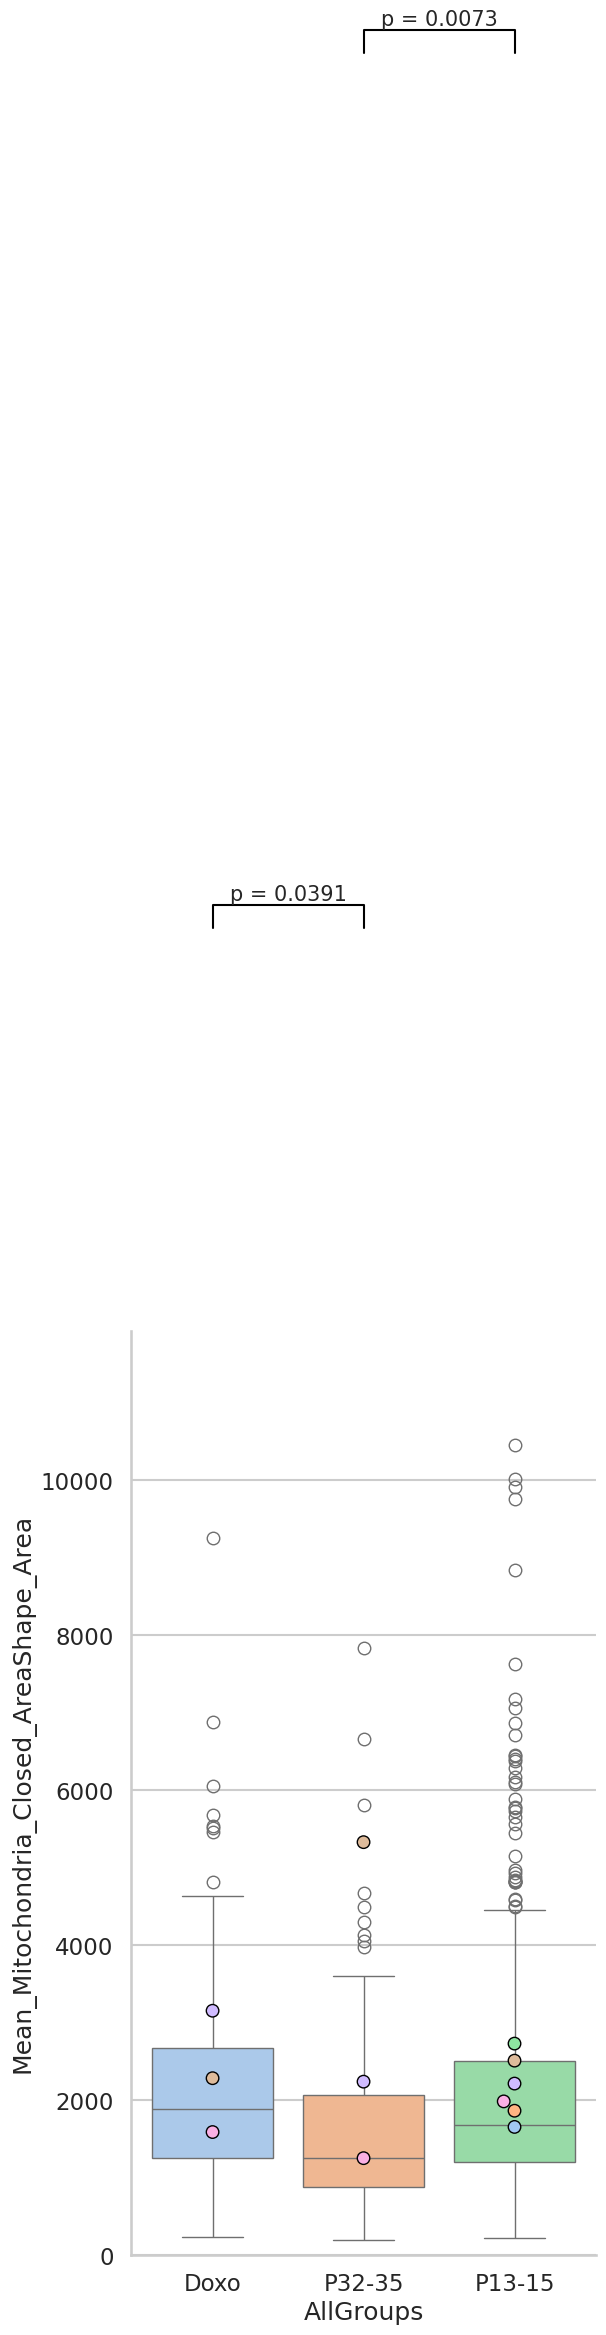

ANOVA F statistic: 30.112343247919434
ANOVA p value: 5.876150712208394e-261
Doxo vs. P32-35: Custom statistical test, P_val:3.360e-02
P32-35 vs. P13-15: Custom statistical test, P_val:0.000e+00
Doxo vs. P13-15: Custom statistical test, P_val:0.000e+00


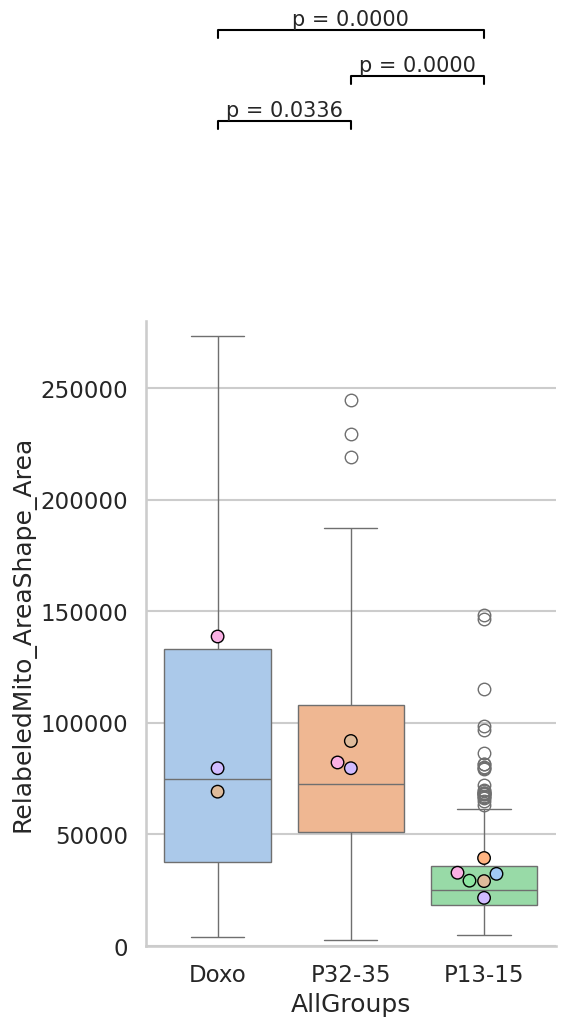

In [36]:
def plot_boxplots_with_swarm_tukey(
    display_df,
    display_df_pivot_plates,
    feature_cols,
    colour_dict=colour_dict,
    size=(6, 10),
    order=None,
    group_col="AllGroups",
    plate_col="Metadata_PlateNumber",
):
    outpath = "segmentation_test/plots_tukey"
    os.makedirs(outpath, exist_ok=True)
    from statannotations.Annotator import Annotator

    if order is None:
        order = display_df[group_col].dropna().unique().tolist()

    for col in feature_cols:
        plt.figure(figsize=size)
        sns.set_style("whitegrid")
        sns.set_context("talk")
        ax = sns.boxplot(
            data=display_df,
            x=group_col,
            y=col,
            palette="pastel",
            fill=True,
            hue=group_col,
            legend=False,
        )
        sns.swarmplot(
            data=display_df_pivot_plates,
            x=group_col,
            y=col,
            palette=colour_dict,
            hue=plate_col,
            dodge=False,
            size=9,
            legend=False,
            linewidth=1,
            edgecolor="k",
        )

        pairs = getpairs(display_df, group_col, order=order)
        pairs, p_values = pvalues_anova_and_tukeyhsd_posthoc(
            display_df,
            display_df_pivot_plates,
            x_value=group_col,
            y_value=col,
            plate_number_col=plate_col,
            desired_pairs=pairs,
            order=order,
        )

        if pairs:
            annotator = Annotator(
                ax=ax,
                pairs=list(pairs),
                data=display_df,
                plot="boxplot",
                x=group_col,
                y=col,
                order=order,
            )
            annotator.reset_configuration()
            annotator.configure(
                text_format="full",
                test_short_name="tukey_v3",
                pvalue_format_string="{:.4f}",
                fontsize="small",
                loc="inside",
                hide_non_significant=True,
                color="black",
                verbose=2,
                line_height=0.01,
                text_offset=0.5,
                show_test_name=False,
            )
            annotator.set_pvalues_and_annotate(p_values)

        sns.despine()
        if display_df[col].dropna().shape[0] > 0:
            upper = np.nanpercentile(display_df[col].dropna(), 99) * 1.2
            if np.isfinite(upper):
                plt.ylim(0, upper)
        plt.tight_layout()
        plt.savefig(os.path.join(outpath, f"{col}_boxplot_tukey.png"))
        plt.show()
        
plot_boxplots_with_swarm_tukey(
    display_df, display_df_pivot_plates, feature_cols, colour_dict, size=(6, 12)
)


# Define the cell features


## Feature lists here:

In [ ]:
feature_dicts = [mito_features, lyso_features, nuc_features, cell_features]
feature_names = [
    "Mitochondria Features",
    "Lysosome Features",
    "Nucleus Features",
    "Cell Features",
]

# Define the output file path
output_file_path = "allfeatures_file.md"

# Open the file in write mode
with open(output_file_path, "w") as file:
    for feature_name, feature_dict in zip(feature_names, feature_dicts):
        file.write(f"# {feature_name}\n\n")
        for feature_type, features in feature_dict.items():
            file.write(f"## {feature_type.capitalize()}\n")
            for feature in features:
                file.write(f'"{feature}",\n')
            file.write("\n")

print(f"List has been written to {output_file_path}")


## Normalize features to control (Passage 6-8)

In [ ]:
# updated/faster version that doesn't use apply and is much faster for large dataframes
all_valid_features = []
for feat_dict in feature_dicts:
    all_cols = [col for cols in feat_dict.values() for col in cols]
    for col in set(all_cols):
        if pd.api.types.is_numeric_dtype(extrafeatures_filtered_cell_df_mitolyso[col]):
            all_valid_features.append(col)
valid_feature_cols = list(
    dict.fromkeys(all_valid_features)
)  # remove duplicates while preserving order
group_col = "AgeGroup"
control_value = 0
norm_combined_cell_df_mitolyso = normalize_quantities_to_control_group_average(
    extrafeatures_filtered_cell_df_mitolyso.copy(),
    valid_feature_cols,
    group_col,
    control_value,
    overwrite=True,
    drop_avg_cols=True,
)
# display(
#     norm_combined_cell_df_mitolyso[
#         ["AllGroups", "Plate_Number", "Metadata_Well"]
#         + valid_feature_cols
#     ]
# )
# norm_combined_cell_df_mitolyso.boxplot(column="Mean_Lysosomes_Distance_Centroid_Cell", by="AllGroups")
# norm_combined_cell_df_mitolyso.groupby(["Plate_Number", "AllGroups"])[
#     "Mean_Lysosomes_Distance_Centroid_Cell"
# ].describe()

In [ ]:
def allgroups_sort_key(value):
    """Custom sort key function for 'AllGroups' column."""
    import re

    match = re.match(r"P(\d+)", value)
    if match:
        first_number = match.group(1)
        if first_number.isdigit():
            return int(first_number)
        else:
            return 99999
    return 99999


print(allgroups_sort_key("P6-10"))

## Helper functions for plot building

In [ ]:
def annotate_pairs_with_calculated_pvalues_test(
    ax,
    data,
    pivot_data,
    x_value,
    y_value,
    plate_col_name="Plate_Name",
    test_name="tukey",
    pairs=None,
    order=None,
    plot_type="violinplot",
    show_test_name=False,
    p_correction="fdr_bh",
    annotation_location="inside",
):
    """Add statistical annotations to a plot using a multiple comparisons test in the statsmodels, scipy, or scikit-posthocs modules.
    see https://statannotations.readthedocs.io/en/latest/custom-test.html for more examples
    Also see https://www.graphpad.com/guides/prism/latest/statistics/stat_summary_of_multiple_comparison.htm for a list of posthoc tests and when to use them

    Args:
        ax (Matplotlib Axes Object): the axis of the graph to annoate
        data (DataFrame): dataframe from a grouped feature df containing the groups aggregated by plate to analyze in "tidy" format
        pivot_data (DataFrame): the grouped feature df in matrix format
        x_value (str): independent variable on x axis
        y_value (str): dependent variable on y axis
        plate_col_name (str, optional): the col containing the experimental plate. Defaults to "Plate_Name".
        test_name (str, optional): the statistical test to perform. Accepts values of "tukey", "anova", or "tukey_v2", for ANOVA with Tukey's HSD, "tukey_v3" for ANOVA with Tukey HSD with Tukey-Kramer correction, "games-howell" or "games" for ANOVA with Games-Howell posthoc, "rmanova" for repeated-measures ANOVA using Welch's ttest with the specified p-value correction, "kruskal" or "dunn" for classic nonparametric multiple comparisons with Dunn's postc, "conover" for kruskal with Conover's posthoc, "nemenyi" for kruskal (or friedman) with Nemenyi's posthoc for repeated measures, "pairwise_ttest" for corrected ttests, "pairwise_mwu" for nonparametic multiple comparisons. Defaults to "tukey".
        pairs (list of str, optional): The pairs of x_value for the comparisons. Defaults to None, is automatically calculated otherwise based on the getpairs() function.
        order (listlike, optional): _description_. Defaults to None.
        plot (str, optional): the type of plot to annotate. Defaults to "violinplot".
        p_correction (str, optional): the p-value correction to use if applicable. Deaults to Benjamini/Hochberg "fdr_bh" (non-negative) method ; graphpad reccomneds as its less hemmoraging to your power. Also accepts "holm", "sidak", "bonferroni", "holm-sidak" and Benjamini/Yekutieli "fdr-by" for negative values. See https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_mannwhitney.html for other options

    Returns:
        _type_: _description_
    """
    from statannotations.Annotator import Annotator

    if pairs is None:
        pairs = getpairs(data, x_value, order=order)

    # nonparametric tests
    if test_name in ["kruskal", "dunn", "kruskal-wallis"]:
        used_pairs, p_values = kruskal_with_dunn_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["drubin", "drubin_posthoc"]:
        used_pairs, p_values = kruskal_with_drubin_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["conover", "con", "kruskal-conover"]:
        used_pairs, p_values = kruskal_with_conover_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["nemenyi", "kruskal-nemenyi"]:
        used_pairs, p_values = kruskal_with_nemenyi_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            display_results=True,
            p_correction=p_correction,
        )
    # parametric tests
    elif test_name in ["anova", "tukey", "tukeyhsd"]:
        # perform anova and tukey's post-hoc test
        used_pairs, p_values = pvalues_anova_and_tukeyhsd_posthoc(
            data, pivot_data, x_value, y_value, order=order, desired_pairs=pairs
        )
    elif test_name in ["games", "games-howell"]:
        used_pairs, p_values = pvalues_anova_with_games_howell_pingouin(
            data,
            pivot_data,
            x_value,
            y_value,
            order=order,
            desired_pairs=pairs,
            display=True,
        )
    elif test_name in ["tahmane", "tahmane-t2"]:
        used_pairs, p_values = anova_with_tahmane_posthoc(
            data,
            x_value,
            y_value,
            order=order,
            desired_pairs=pairs,
            display_results=True,
        )
    elif test_name in ["tukey_v2", "tukey_posthocs"]:
        used_pairs, p_values = anova_with_tukey_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            plate_number_col=plate_col_name,
            order=order,
            desired_pairs=pairs,
            display_results=True,
        )
    elif test_name in ["tukey_v3", "tukey_pingouin"]:
        used_pairs, p_values = pvalues_anova_with_tukey_pingouin(
            data,
            pivot_data,
            x_value=x_value,
            y_value=y_value,
            plate_number_col=plate_col_name,
            order=order,
            desired_pairs=pairs,
            display=True,
        )
    elif test_name in ["pairwise_ttest" or "multiple_ttest"]:
        used_pairs, p_values = pvalues_anova_with_pairwise_tests_pingouin(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            pval_correction=p_correction,
            parametric=True,
            display=True,
        )
    elif test_name in [
        "pairwise_mwu"
        or "multiple_mwu"
        or "pairwise_mannwhitney"
        or "multiple_mannwhitney"
        or "pairwise_wilcoxon"
        or "multiple_wilcoxon"
    ]:
        used_pairs, p_values = pvalues_anova_with_pairwise_tests_pingouin(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            pval_correction=p_correction,
            parametric=False,
            display=True,
        )
    elif test_name in ["ttest_posthoc", "welch's_posthoc", "tt_posthoc"]:
        used_pairs, p_values = anova_with_corr_ttest_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_corr=p_correction,
            display_results=True,
        )
    else:
        raise ValueError(
            f"Test name '{test_name}' is invalid. Use 'tukey', 'anova', 'kruskal', 'games-howell', 'drubin', 'tukey_v2', or 'dunn'."
        )
    if used_pairs is None or len(used_pairs) == 0:
        print(f"No significant pairs found for the {test_name} test.")
        return ax
    else:
        annotator = Annotator(
            ax=ax,
            pairs=list(used_pairs),
            data=data,
            plot=plot_type,
            x=x_value,
            y=y_value,
            order=order,
        )
        annotator.reset_configuration()
        # see https://raw.githubusercontent.com/trevismd/statannotations/3f020ae631ca88a091b6ee3e9a9fd32158920879/usage/example_tuning_y_offsets_w_arguments.png
        annotator.configure(
            text_format="full",
            test_short_name=test_name,
            pvalue_format_string="{:.4f}",
            fontsize="small",
            # pvalue_format = [[1e-5, "1e-5"], [1e-4, "1e-4"], [1e-3, "0.001"], [1e-2, "0.01"], [5e-2, "0.05"]],
            loc=annotation_location,
            hide_non_significant=True,
            color="black",
            verbose=2,
            line_height=0.01,
            text_offset=0.8,
            # line_offset_to_group=0.01,
            # line_offset=0.01,
            show_test_name=show_test_name,
        )
        annotator.set_pvalues_and_annotate(p_values)
        return ax


def super_splitviolinplot_helper_singleplot(
    data_df,
    group_avg_df,
    ax,
    x_value,
    y_value,
    title,
    plate_col_name,
    pairs=None,
    order=None,
    annotate=False,
    test=None,
    shapiro=True,
    show_test_on_plot=False,
    pallete=None,
    p_correction="bonf",
    annotation_location="inside",
):
    group_avg_df = group_avg_df.copy()
    if pairs is None:
        pairs = getpairs(data_df, x_value, order=order)

    if pallete is None:
        pallete = get_hard_code_plate_colours(group_avg_df)
    print(pairs)
    sns.violinplot(
        data=data_df,
        x=x_value,
        y=y_value,  # hue=x_value,
        # palette="Set2",
        split=True,  # using split violin plots - only one side, basically looks like a histogram
        inner="quart",
        color="gainsboro",
        dodge=False,
        # fill = True
        width=1,
        linewidth=1.5,
        order=order,
        ax=ax,
        cut=0.5,
    )
    # add in the colour scheme
    unique_plates = group_avg_df[plate_col_name].unique()
    group_avg_df[plate_col_name] = pd.Categorical(
        group_avg_df[plate_col_name], categories=unique_plates
    )
    sns.swarmplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        hue=plate_col_name,
        order=order,
        palette=pallete,
        size=10,
        edgecolor="k",
        linewidth=1,
        dodge=False,
        ax=ax,
    )
    # draw a boxplot to show the mean line
    sns.boxplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        showmeans=True,
        meanline=True,
        meanprops={"color": "dimgray", "ls": "-", "lw": 4},
        medianprops={"visible": False},
        whiskerprops={"visible": False},
        zorder=2,
        showfliers=False,
        showbox=False,
        showcaps=False,
        ax=ax,
    )
    ax.set_title(title)

    # use pivot table to get the average values for each group
    if annotate and test is not None:
        group_avg_pivot_table = average_groups_pivot(
            group_avg_df, x_value, y_value, plate_col_name
        )
        try:
            ax = annotate_pairs_with_calculated_pvalues_test(
                ax,
                group_avg_df,
                group_avg_pivot_table,
                x_value,
                y_value,
                plate_col_name=plate_col_name,
                test_name=test,
                order=order,
                plot_type="violinplot",
                show_test_name=show_test_on_plot,
                p_correction=p_correction,
                annotation_location=annotation_location,
            )
        except Exception as e:
            print(f"Error annotating with statistical test: {e}")
            # ax = annotate_with_anova_tukey(ax, pairs, group_avg_df_pivot, x_value, y_value, plate_col_name=plate_col_name, order=order, plot="violinplot")
        # elif test == "kruskal":
        #     ax = annotate_with_kruskal(
        #         ax,
        #         pairs,
        #         group_avg_pivot_table,
        #         x_value,
        #         y_value,
        #         order=order,
        #         plate_col_name=plate_col_name,
        #         plot="violinplot",
        #     )
        if shapiro:
            ax = annotate_legend_with_shapiro(ax, group_avg_df, plate_col_name)

    return ax


def single_feature_super_splitviolinplot(
    data_df,
    x_value="AllGroups",
    y_value="Cell_AreaShape_Area",
    plate_col_name="Plate_Number",
    out_dir=Path(""),
    xtitle=None,
    ytitle=None,
    order=None,
    legend=True,
    annotate=False,
    test=None,
    show_hist=False,
    remove_outliers=False,
    rm_outliers_method="mad",
    ylim=None,
    reps_to_exclude=[],
    shapiro=True,
    show=True,
    context="talk",
    font_scale=1.2,
    figsize=(8, 6),
    truncate_outliers=False,
    norm=False,
    pallete=None,
    p_correction="bonf",
    annotation_location="inside",
):
    """Make a superplot to do multiple comparisons for a feature between different conditions
    Args:
        data_df_1 (_type_): _description_
        group_avg_df_1 (_type_): _description_
        data_df_2 (_type_): _description_
        group_avg_df_2 (_type_): _description_
        x_value (str, optional): _description_. Defaults to "AllGroups".
        y_value (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        plate_col_name (str, optional): _description_. Defaults to "Plate_Number".
        csv_dir (str, optional): _description_. Defaults to "".
        xtitle (_type_, optional): _description_. Defaults to None.
        ytitle (_type_, optional): _description_. Defaults to None.
    """
    import matplotlib.lines as mlines
    from statannotations.Annotator import Annotator
    from statannotations.stats.StatTest import StatTest
    from pathlib import Path

    if order == None:
        order = get_all_group_order()
    pairs = getpairs(data_df, x_value, order=order)
    print(pairs)
    if truncate_outliers:
        try:
            bottom_fence = None  # np.percentile(data_df[y_value], 0.000001)
            if norm:
                top_fence = data_df[y_value].mean() + 10 * data_df[y_value].std()
            else:
                top_fence = np.percentile(data_df[y_value], 99.9)
                # handle errors where the data is very skewed and the percentile is inf or nan
                if top_fence == 0 or np.isnan(top_fence) or np.isinf(top_fence):
                    top_fence = None
            axlim = (bottom_fence, top_fence)
        except ValueError as e:
            print(e)
            top_fence = None
            bottom_fence = None
            axlim = (None, None)
    else:
        axlim = (None, None)

    df_sorted = data_df.sort_values(
        by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    if show_hist:
        hist = sns.kdeplot(
            df_sorted, x=y_value, hue=plate_col_name, palette=pallete, multiple="layer"
        )
        plt.xlim(axlim)
        plt.savefig(f"{Path(out_dir, f'{y_value}_{plate_col_name}_histogram')}.png")
        plt.show()
        plt.close()
        hist2 = seaborn_ridgeplot(
            df_sorted,
            value_col=y_value,
            group_col=x_value,
            palette="Set2",
            save=True,
            out_dir=out_dir,
            show_percentiles=True,
        )
        plt.close()
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_theme(style="ticks", context=context, font_scale=font_scale)

    feature_df = df_sorted[[x_value, y_value, plate_col_name]].copy()
    if reps_to_exclude:
        feature_df = feature_df[~feature_df[plate_col_name].isin(reps_to_exclude)]
        print(f"removing plates: {reps_to_exclude}")

    # remove outluers
    if remove_outliers is True:
        if rm_outliers_method == "mad":
            feature_df = flag_outliers_by_group_mad(feature_df, x_value, y_value)
            feature_df = feature_df[~feature_df["Outlier"]]
        elif rm_outliers_method == "gesd":
            feature_df = flag_outliers_by_group_gesd(
                feature_df, x_value, y_value, noutliers=50
            )
            feature_df = feature_df[~feature_df["Outlier_GESD"]]
        elif rm_outliers_method == "gesd_2":
            print(feature_df.shape)
            feature_df = remove_outliers_by_group_gesd(
                feature_df, x_value, y_value, noutliers=500
            )
            print(feature_df.shape)
        elif rm_outliers_method == "tietjen":
            feature_df = remove_outliers_by_group_tietjen(
                feature_df, x_value, y_value, noutliers=50
            )
        elif rm_outliers_method == "iqr":
            feature_df = remove_outliers_iqr(feature_df)
        else:
            ValueError(f"{rm_outliers_method} is not a valid outlier removal method")
        # display(feature_df)

    # group by plate and condition
    group_avg_df = feature_df.groupby([x_value, plate_col_name], as_index=False).mean()
    # sort the group avg df by the "AllGroups" order
    group_avg_df_sorted = group_avg_df.sort_values(
        by=[x_value], key=lambda x: x.map(allgroups_sort_key)
    ).reset_index(drop=True)

    ax = super_splitviolinplot_helper_singleplot(
        feature_df,
        group_avg_df_sorted,
        ax,
        x_value,
        y_value,
        title=" ",
        plate_col_name=plate_col_name,
        pairs=pairs,
        order=order,
        annotate=annotate,
        test=test,
        shapiro=False,
        pallete=pallete,
        p_correction=p_correction,
        annotation_location=annotation_location,
    )

    if legend:
        ax.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=True,
            title=plate_col_name,
        )
        if shapiro:
            group_avg_df_shapiro = apply_shapiro_wilk_test_to_df(
                group_avg_df_sorted,
                feature_meas=y_value,
                plate_col_name="Plate_Number",
                alpha=0.05,
            )
            # display(group_avg_df_shapiro)
            ax = annotate_legend_with_shapiro(ax, group_avg_df_shapiro, plate_col_name)
    else:
        ax.legend_.remove()
    if ytitle is not None:
        ax.set_ylabel(ytitle)
    else:
        ax.set_ylabel(y_value.replace("_", " "))
    if xtitle is not None:
        ax.set_xlabel(xtitle)

    # Set the ylim and don't throw an inf
    if ylim is None:
        ylim = axlim
    if ylim[0] is not None and ylim[1] is not None:
        if not (
            np.isnan(ylim[0])
            or np.isnan(ylim[1])
            or np.isinf(ylim[0])
            or np.isinf(ylim[1])
        ):
            ax.set_ylim(ylim)
    plt.tight_layout()
    sns.despine(trim=True)
    plt.savefig(os.path.join(out_dir, f"{y_value}_{test}.png"))
    if show:
        plt.show()

## Make a plot for a single feature

In [ ]:
order = get_all_group_order()
feature_meas = "AreaShape_Area"  # "AreaShape_Area"#Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area" #Mean_Lysosomes_DiameterRatio_PerCell"
ylabel = None  # "Mitochondrial Density Per Cell (relative to youngest passage)"#None#"Mitochondria per cell"
xlabel = "Age Groups"
group = "AllGroups"

pairs = getpairs(combined_cell_df_mitolyso, group, order)

# this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
this_df = norm_combined_cell_df_mitolyso.copy()

data_df = this_df  # >3500]   #Potentially use a theshold - this is the trough of the nuc size peak at 0
# this_df = extrafeatures_filtered_cell_df_mitolyso.copy()

# Map each plate to a color and hard code that shit
colour_dict = get_hard_code_plate_colours(data_df)
pallete = colour_dict  # "pastel"

remove_outliers = False
reps_to_exclude = []
plot_dir = "plots/notnorm"
os.makedirs(plot_dir, exist_ok=True)

figsize = (13, 12)

single_feature_super_splitviolinplot(
    data_df,
    x_value=group,
    y_value=feature_meas,
    plate_col_name="Plate_Number",
    xtitle=xlabel,
    ytitle=ylabel,
    out_dir=plot_dir,
    annotate=True,
    order=order,
    test="tukey_v3",
    reps_to_exclude=reps_to_exclude,
    show_hist=False,  # True,
    remove_outliers=remove_outliers,
    rm_outliers_method="gesd_2",
    truncate_outliers=True,
    legend=True,
    context="talk",
    font_scale=0.8,
    figsize=figsize,
    pallete=pallete,
    p_correction="fdr_bh",
    annotation_location="inside",
    # truncate_outliers=True
)

# NOTE: R5 has smallest cells in p23-25, which is also highest mito density

## Make multiple plots as defined

In [ ]:
# take feature : label pairs to be used for plots from csv
features_df = pd.read_csv("CP_features_for_plots.csv")
display(features_df[features_df["feature"] == "AreaShape_Area"])

data_df = extrafeatures_filtered_cell_df_mitolyso.copy()
# Use in plotting loops with guaranteed alignment:


def make_feature_plots_from_csv(
    data_df,
    features_df,
    xlabel="Age Groups",
    group="AllGroups",
    analysis_mode="Plates",
    norm=False,
    order=None,
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(14, 18),
    truncate_outliers=True,
    rm_outliers_method="gesd_2",
    annotate_pval=True,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
    show_legend=False,
):
    features_for_plots = features_df.to_dict("records")

    feature_df_cols = [item["feature"] for item in features_for_plots]
    feature_labels = [item["label"] for item in features_for_plots]

    if order is None:
        order = get_all_group_order()
    pairs = getpairs(data_df, group, order)

    # Set stats variables and color palette based on analysis mode
    if analysis_mode == "Lineages":
        stat_grouping = "Lineage"
        plot_dir = Path("plots/lineages")
        show_legend = True
        colour_dict = get_hard_code_lineage_colours(data_df)
    elif analysis_mode == "Plates":
        stat_grouping = "Plate_Number"
        colour_dict = get_hard_code_plate_colours(data_df)
        if norm:
            data_df = norm_combined_cell_df_mitolyso.copy()
            feature_labels = [
                f"{name} (normalized to youngest group)" for name in feature_labels
            ]
            plot_dir = Path("plots/norm")
        else:
            data_df.copy()
            data_df = data_df[data_df["MitoEnds_NumberBranchEnds_PerCell_Area"] > 0]
            plot_dir = Path("plots/notnorm")
            
    else:
        raise ValueError(
            f"Invalid analysis mode: {analysis_mode}. Use 'Lineages' or 'Plates'."
        )
    pallete = colour_dict  # "pastel"

    os.makedirs(plot_dir, exist_ok=True)
    for i, feature in enumerate(feature_df_cols):
        ylabel = feature_labels[i]

        single_feature_super_splitviolinplot(
            data_df,
            x_value=group,
            y_value=feature,
            plate_col_name=stat_grouping,
            xtitle=xlabel,
            ytitle=ylabel,
            out_dir=plot_dir,
            annotate=annotate_pval,
            order=order,
            test=test,
            reps_to_exclude=reps_to_exclude,
            show_hist=False,  # True,
            remove_outliers=remove_outliers,
            rm_outliers_method=rm_outliers_method,
            truncate_outliers=truncate_outliers,
            legend=show_legend,
            context="talk",
            figsize=figsize,
            pallete=pallete,
            p_correction="fdr_bh",
            shapiro=False,
            font_scale=font_scale,
            annotation_location=annotation_location,
        )


make_feature_plots_from_csv(
    data_df,
    features_df,
    norm=True,
    analysis_mode="Plates",
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(13, 12),
    annotate_pval=True,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
)